<h1><center> Chapitre II :</center></h1>
<h1><center> Classification Multiclasse<br><i>- Fleurs d'Iris -</i></center></h1>
<hr>

## Motivation et Objectifs

Après avoir exploré les algorithmes de classification (SVM, Régression Logistique, Naive Bayes) dans le cadre de notre projet sur l'analyse de sentiments pour de la classification binaire, nous étendons maintenant la classification binaire au contexte du **multi-classe**.

Dans cette deuxième partie, l’objectif sera d’abord d’appliquer les algorithmes déjà étudiés (SVM, Régression Logistique, Naive Bayes) à un problème de classification multi‑classe, afin d’observer comment ils se comportent dans un cadre plus riche que la simple classification binaire. Nous explorerons également en profondeur deux nouveaux algorithmes : le K‑Nearest Neighbors (KNN) et le Decision Tree, afin de découvrir de nouvelles approches pour résoudre un problème de classification.

Enfin, pour comparer les différents modèles, nous travaillerons sur le **dataset Iris** connu pour sa simplicité (150 observations, 4 features continues, 3 classes). La faible dimensionnalité du dataset nous permettra de *voir* ce qui restait caché dans les espaces de grande dimension du chapitre I (comme les frontières de décision, l'effet du surapprentissage, l'importance relative des features) et d'établir des liens directs entre l'analyse exploratoire des données et les performances de chaque modèle. Concrètement, l'objectif de ce chapitre est de comprendre comment l'analyse de la distribution des données, peut permettre d'interpréter, et parfois d'anticiper, le niveau de performances d'un modèle.

Ce chapitre se découpera donc en cinq sections :

1. **Le dataset Iris** : analyse exploratoire et préparation des données
2. **Généralisation au multiclasse** des méthodes du chapitre I (SVM, Régression Logistique, Naive Bayes)
3. **K-Nearest Neighbors** : classification sans modèle par voisinage local
4. **Arbres de décision** : partition hiérarchique de l'espace des features
5. **Analyse comparative et recommandations**

### Importation des librairies

In [ ]:
import numpy as np
import pandas as pd
import time

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn import svm
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_squared_error, r2_score

# Choix des palettes
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
BACKGROUND_CMAP = "PiYG"

## I. Le dataset Iris : Analyse exploratoire des données

### I.1. Présentation du dataset

Le dataset Iris, introduit par Ronald Fisher en 1936, est l'un des benchmarks les plus utilisés pour commencer l'apprentissage automatique. Il décrit 150 fleurs réparties en trois espèces (*Iris setosa*, *Iris versicolor* et *Iris virginica*) par quatre mesures continues : longueur et largeur des sépales, longueur et largeur des pétales (en centimètres). Les trois classes y sont parfaitement équilibrées, avec 50 observations chacune.

Ce qui nous interessera particulièrement dans ce dataset est la distribution des classes. En effet, la fleur d'iris *setosa* est linéairement séparable des deux autres espèces dans la plupart des sous-espaces 2D, tandis que *versicolor* et *virginica* se chevauchent partiellement, ce qui nous permettra de voir en pratique les limites des modèles linéaires.

Le dataset est diponible sur Kaggle depuis : [kaggle.com](https://www.kaggle.com/datasets/uciml/iris)

In [129]:
import os

columns=["SepalLengthCm","SepalWidthCm","PetalLengthCm","PetalWidthCm","Species"]

path = os.path.join("data", "iris-classification", "iris_data.csv")
dataset = pd.read_csv(path, names=columns)

display(dataset.head())
display(dataset.tail())

print(f"Dimensions du dataset: {dataset.shape}")
print(f"\nNombre d'observations: {dataset.shape[0]}")
print(f"Nombre de features: {dataset.shape[1] - 1}")
print(f"\nRépartition des classes:")
print(dataset['Species'].value_counts())

missing = dataset.isnull().sum()
if missing.sum() == 0:
    print("\nAucune valeur manquante - dataset complet")
else:
    print("\nValeurs manquantes :", missing.to_dict())


HEAD:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa



TAIL:


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


Dimensions du dataset: (150, 5)

Nombre d'observations: 150
Nombre de features: 4

Répartition des classes:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Aucune valeur manquante - dataset complet


<br>

### I.2. Analyse exploratoire des données (EDA)

Pour étudier la séparabilité des classes, on réalise donc une analyse exploratoire des données dans différents sous-espaces de $\mathbb{R}^d$, à l'aide de plusieurs graphiques que l'on détaillera.

Les conclusions que nous en déduirons seront directement utile pour le choix des modèles. En effet, un espace linéairement séparable justifie un noyau linéaire pour la SVM, un chevauchement fort justifie une marge souple avec un $C$ modéré, et une forte corrélation entre features prédit les difficultés de Naive Bayes.

#### I.2.1. Analyse univariée

Commençons par étudier les distributions marginales pour chaque classe d'une features comme la longueur des pétales, afin de réaliser une première visualisation des zones de chevauchement entre classes.

<Figure size 1200x600 with 0 Axes>

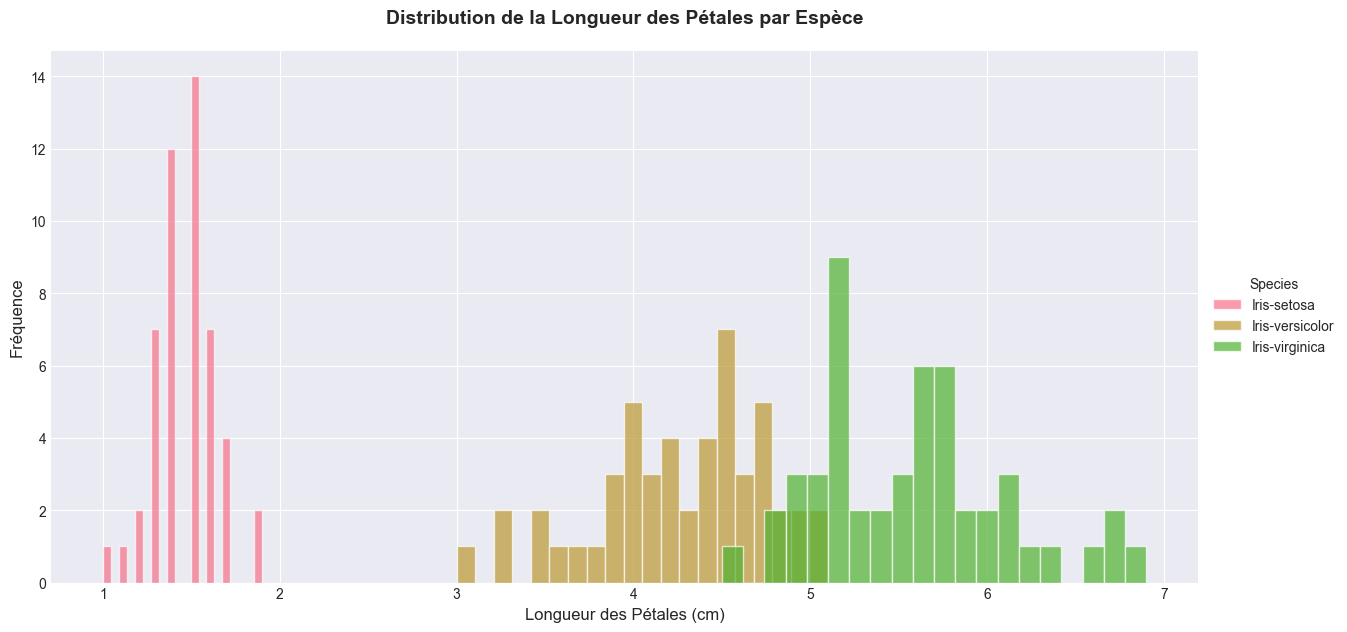

In [130]:
plt.figure(figsize=(12, 6))
grid = sns.FacetGrid(dataset, hue="Species", height=6, aspect=2)
grid.map(plt.hist, "PetalLengthCm", bins=20, alpha=0.7).add_legend()
plt.title('Distribution de la Longueur des Pétales par Espèce', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Longueur des Pétales (cm)', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.show()

La distribution de la longueur des pétales révèle ainsi la séparation entre les valeurs de *setosa* (concentrées entre 1 et 2 cm) et celles de *versicolor* et *virginica* (entre 3 et 7 cm). En revanche, les distributions de ces deux dernières espèces se chevauchent assez significativement entre 4,5 et 5,5 cm.

Dans ce sens, un classifieur même très simple (un seuil unique sur PetalLength) suffirait à isoler *setosa* parfaitement, tandis que distinguer *versicolor* de *virginica*, exigera de combiner plusieurs features ou de recourir à des frontières non linéaires.

#### I.2.2. Analyse bivariée

La limite des distributions univariées est qu'elles ne montrent qu'une projection sur un axe. Les diagrammes de dispersion (ou *scatterplots*), permettent quant à eux de révéler les relations entre paires de features et permettent ainsi d'évaluer la séparabilité dans des sous-espaces 2D, ce qui est déjà plus proche de ce que les modèles linéaires exploitent réellement.

Par exemple, si on regarde le diagrammes de dispersion par classes dans l'espace des sépales :

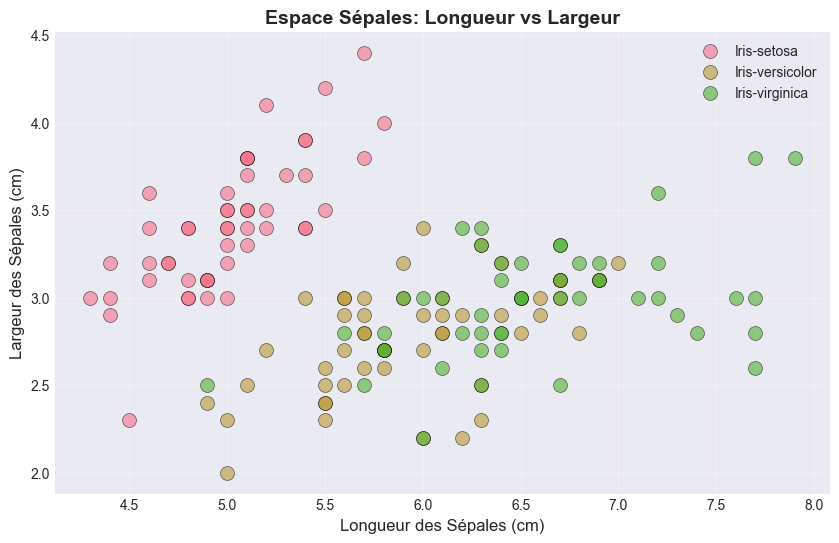

In [131]:
plt.figure(figsize=(10, 6))
for species in dataset['Species'].unique():
    subset = dataset[dataset['Species'] == species]
    plt.scatter(subset['SepalLengthCm'], subset['SepalWidthCm'], 
                label=species, alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
plt.xlabel('Longueur des Sépales (cm)', fontsize=12)
plt.ylabel('Largeur des Sépales (cm)', fontsize=12)
plt.title('Espace Sépales: Longueur vs Largeur', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

On peut voir que *setosa* se distingue par une largeur plus élevée que les deux autres espèces. Cependant, les trois classes sont loin d'être proprement séparées puisque *versicolor* et *virginica* forment un nuage presque indistinct, et même *setosa* contient un point qui ne serait pas classifié comme appartenant à sa clase. Un classifieur linéaire dans cet espace commettrait donc nécessairement des erreurs sur les deux espèces les plus proches.

Néanmoins, si on s'intéresse au diagramme de dispersion dans l'espace des pétales : 

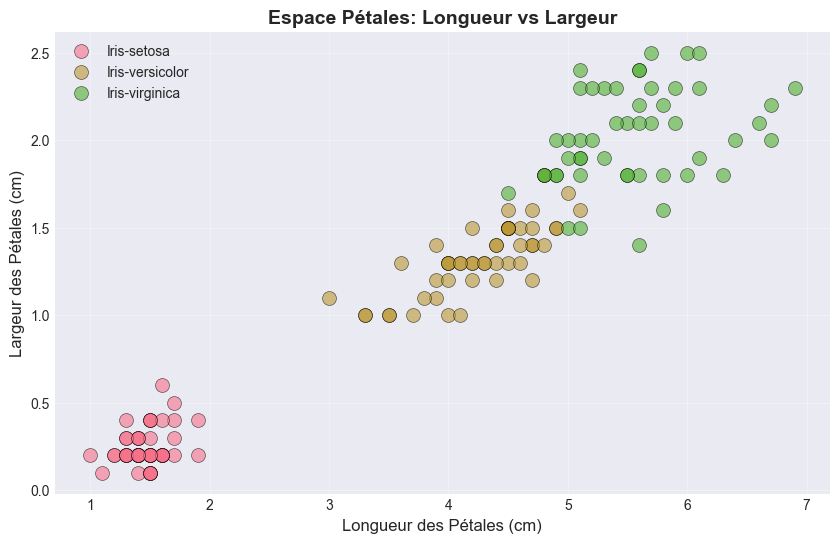

In [132]:
plt.figure(figsize=(10, 6))
for species in dataset['Species'].unique():
    subset = dataset[dataset['Species'] == species]
    plt.scatter(subset['PetalLengthCm'], subset['PetalWidthCm'], 
                label=species, alpha=0.6, s=100, edgecolors='black', linewidth=0.5)
plt.xlabel('Longueur des Pétales (cm)', fontsize=12)
plt.ylabel('Largeur des Pétales (cm)', fontsize=12)
plt.title('Espace Pétales: Longueur vs Largeur', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.show()

Cette fois-ci, on peut voir que *setosa* y forme un cluster compact et parfaitement isolé dans le coin inférieur gauche. Et même si *versicolor* et *virginica* restent partiellement chevauchées, leur séparation est bien plus nette qu'avec les sépales. Une frontière linéaire dans cet espace classerait donc correctement la grande majorité des points.

En pratique, on considèrera donc que les features liées aux pétales jouent un rôle plus déterminants que les autres features dans les modèles. Une observation que l'on confirmera avec l’analyse des coefficients de la régression logistique et via l'importance Gini des arbres de décision.

#### I.2.3. Vue d'ensemble : Pairplot

Enfin, la fonction pairplot de seaborn permet de visualiser automatiquement les distributions univariées et les scatterplots pour toutes les paires de features, offrant ainsi une vue d’ensemble de la séparabilité des classes dans chaque sous‑espace 2D.

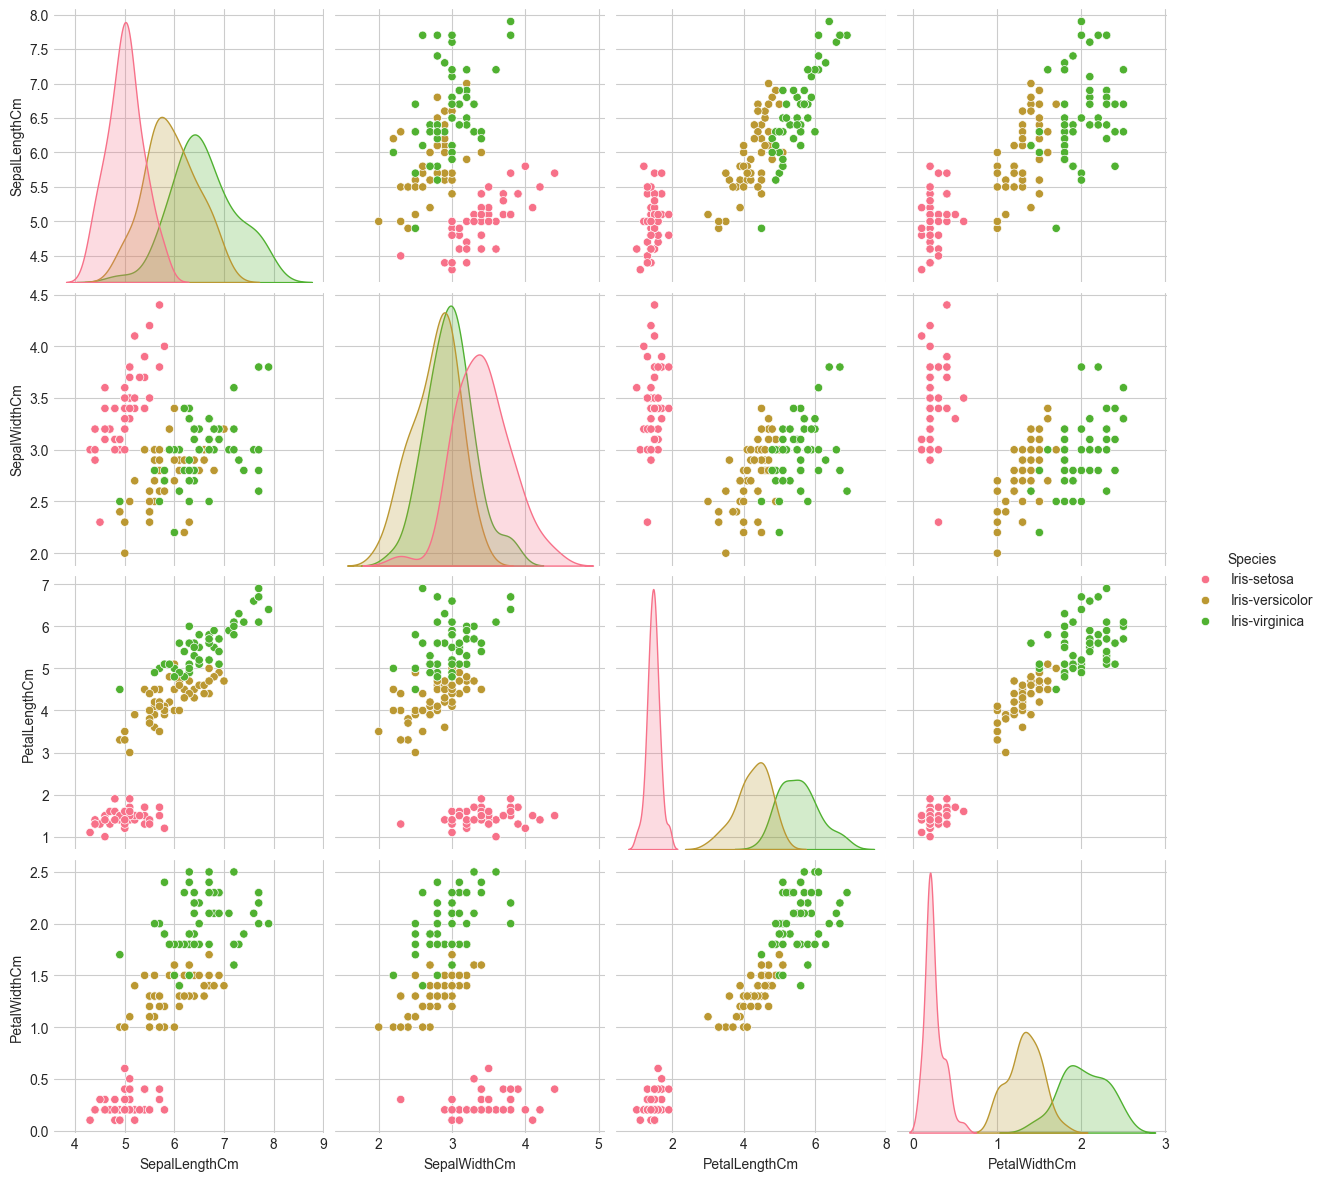

In [133]:
sns.set_style("whitegrid")
sns.pairplot(dataset,hue="Species",height=3,aspect=1)
plt.show()

Finalement, on observe que *setosa* se distingue plus ou moins nettement des autres espèces sur toutes les paires de features, mais de façon bien plus nette dans l'espace des pétales. En revanche, *versicolor* et *virginica* présentent plus ou moins des chevauchements sur toutes les features, ce qui impose de combiner plusieurs variables pour obtenir une bonne classification. 

On pourra aussi remarquer que les classes sont globalement compactes avec des écarts‑types plutôt faibles par rapport aux moyennes. Cette compacité sera favorable à KNN, dont les performances dépendent directement de la cohérence locale des classes.

### I.3. Analyse des Corrélations

Pour compléter l'EDA, on peut utiliser une matrice de corrélation afin de mettre en évidence les relations linéaires entre les features. Ces informations permettent notamment ensuite d’évaluer la validité de l’hypothèse d’indépendance pour Naive Bayes, de détecter d’éventuels risques de multicolinéarité pour la régression logistique, et d’identifier quelles variables mesurent des aspects similaires du problème.

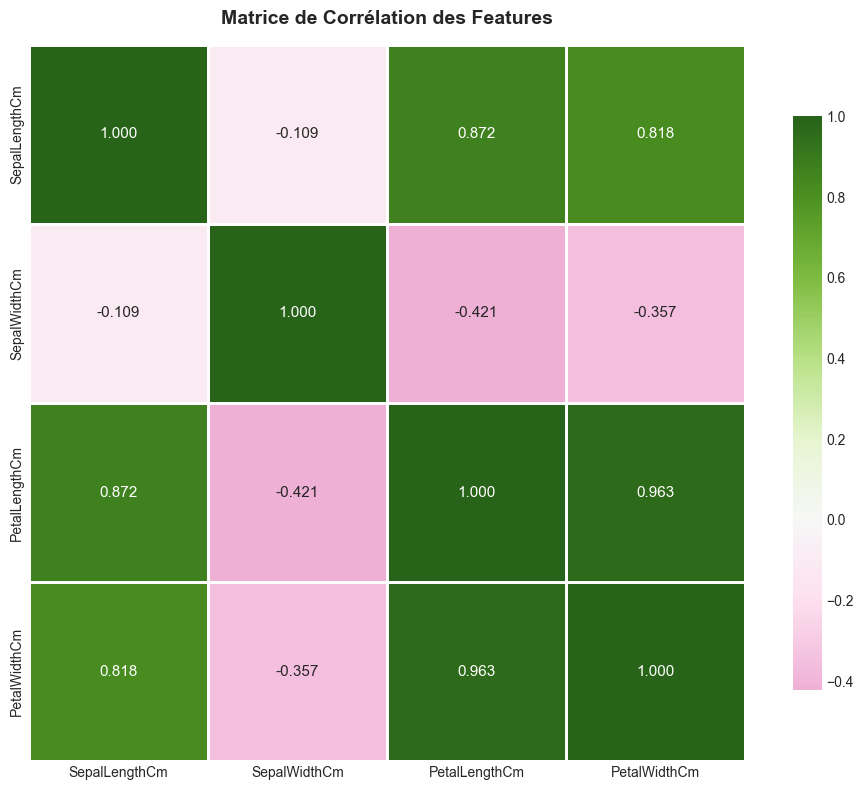

In [134]:
plt.figure(figsize=(10, 8))

correlation_matrix = dataset.drop('Species', axis=1).corr()
sns.heatmap(correlation_matrix, annot=True, cmap=BACKGROUND_CMAP, 
            center=0, square=True, linewidths=1, fmt='.3f',
            cbar_kws={"shrink": 0.8}, annot_kws={'size': 11})
plt.title('Matrice de Corrélation des Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

On peut ainsi voir que PetalLength et PetalWidth sont fortement corrélées ($\simeq 0.96$), ce qui montre que cette paire de features capturent essentiellement la même notion de “taille” des pétales. L’hypothèse d’indépendance de Naive Bayes est donc clairement violée et la régression logistique est exposée à un risque de multicolinéarité, bien que la régularisation permette de gérer cette multicolinéarité. 

De plus, les corrélations modérées ($\simeq 0.87$), notamment entre PetalLength et SepalLength, indiquent de nouveau une redondance partielle liée à la taille globale de la fleur.

Néanmoins, SepalWidth reste faiblement corrélée aux autres variables, ce qui signifie qu'elle ne présente pas de relation linéaire avec les autres features. En effet, d'après l'EDA, on peut voir que toutes les classes partagent généralement la même largeur de sépale. Cette feature pourrait donc probablement être supprimée sans perte de performances. On vérifiera donc cette hypothèse dans l'analyse de l'importance des features pour la régression logistique et les decision tree.

### I.4. Préparation des données

L'analyse exploratoire a donc permis d'identifié les propriétés essentielles du dataset. Avant de passer à la modélisation, il reste à partitionner les données en ensembles d'entraînement et de test.

On utilise un ratio 70/30, ce qui donne 105 points d'entraînement et 45 de test.

**Remarque** : L'utilisation de `stratify` garantit que les proportions de classes sont préservées dans train et test, afin de maintenir la représentativité sur les deux datasets.

In [135]:
train, test = train_test_split(dataset, test_size=0.3, 
                               random_state=42, stratify=dataset['Species'])
nb_point_train = train.shape[0]
liste_nb_point_classe_train = train['Species'].value_counts().tolist()
print(f"Train set: {train.shape}")
print(f"Test set: {test.shape}")
print(f"\nRépartition des classes (train):")
print(train['Species'].value_counts())
print(f"\nRépartition des classes (test):")
print(test['Species'].value_counts())

Train set: (105, 5)
Test set: (45, 5)

Répartition des classes (train):
Species
Iris-versicolor    35
Iris-setosa        35
Iris-virginica     35
Name: count, dtype: int64

Répartition des classes (test):
Species
Iris-virginica     15
Iris-versicolor    15
Iris-setosa        15
Name: count, dtype: int64


On peut ensuite séparer les données entre features et variable cible, puis convertir les DataFrames pandas en tableaux NumPy, le format attendu par scikit-learn.

In [136]:
train_X = train[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
train_y = train.Species
test_X = test[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']] 
test_y = test.Species

X_train = np.array(train_X)
y_train = np.array(train_y)
X_test = np.array(test_X)
y_test = np.array(test_y)

print(f"Dimensions finales:")
print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

Dimensions finales:
X_train: (105, 4), y_train: (105,)
X_test: (45, 4), y_test: (45,)


## II. Généralisation au multiclasse des méthodes du chapitre I

Les trois modèles du chapitre I (SVM, régression logistique et Naive Bayes) ont été présentés dans un cadre binaire (où $\mathcal{Y} = \{-1, +1\}$). Leur extension au multiclasse soulève dans chaque cas une question différente. 

### II.1. Formalisation du problème multiclasse

Dans un problème de **classification multiclasse**, on cherche à apprendre une fonction $f : \mathbb{R}^d \to \{1, \ldots, K\}$ depuis un corpus d'entraînement $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^n$, où $\mathbf{x}_i \in \mathbb{R}^d$ et $y_i \in \{1, \ldots, K\}$, avec $K \geq 3$.

En termes probabilistes, cela revient à modéliser la distribution conditionnelle $p_\theta(y \mid \mathbf{x})$ sur $K$ valeurs plutôt que deux. La règle de décision générale reste la même qu'en binaire :

$$\hat{y} = \arg\max_{k \in \{1,\ldots,K\}} P(y = k \mid \mathbf{x})$$

Ce qui change, c'est la façon dont chaque famille de modèles représente et calcule ces $K$ probabilités. La SVM, intrinsèquement binaire, doit combiner plusieurs classifieurs. La régression logistique doit remplacer la sigmoïde (qui ne produit qu'une probabilité scalaire) par une distribution sur $K$ classes. Naive Bayes, lui, étend son $\arg\max$ à $K$ termes sans aucune autre modification. C'est ce que nous allons détailler dans les sections suivantes.

### II.2. Support Vector Machine (SVM)

Dans notre projet précédent sur l'analyse de sentiments, nous avons pu explorer les **Support Vector Machines** dans un contexte de classification binaire. Pour rappel, la SVM cherche l'hyperplan $\mathbf{w}^T\mathbf{x} + b = 0$ qui maximise la marge $\frac{2}{\|\mathbf{w}\|}$ entre les deux classes, en résolvant :

$$\min_{\mathbf{w}, b,\, \boldsymbol{\xi}} \quad \frac{1}{2}\|\mathbf{w}\|^2 + C\sum_{i=1}^n \xi_i \qquad \text{tel que} \quad y_i(\mathbf{w}^T \mathbf{x}_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0$$

La formulation duale du problème fait apparaitre le fait que la décision dépend uniquement des produits scalaires $\mathbf{x}_i^T \mathbf{x}$. Le kernel trick les remplace donc par $K(\mathbf{x}_i, \mathbf{x})$ pour travailler implicitement dans un espace de dimension supérieure :

$$f(\mathbf{x}) = \text{sign}\!\left(\sum_{i=1}^n \alpha_i y_i\, K(\mathbf{x}_i, \mathbf{x}) + b\right)$$

#### II.2.1. Extension au multiclasse : OvR et OvO

Comme la SVM est intrinsèquement binaire, pour gérer $K > 2$ classes, on distingue deux stratégies principales.

La stratégie **One-vs-Rest (OvR)** : où on entraîne $K$ classifieurs indépendants, tel que le $k$-ième classifieur oppose la classe $k$ à toutes les autres. Chaque classifieur $k$ résout ainsi le problème SVM habituel avec $y_i^{(k)} = +1$ si $y_i = k$, $-1$ sinon. La classe prédite est celle dont le score de confiance $(\mathbf{w}^{(k)})^T\mathbf{x} + b^{(k)}$ est le plus élevé :

$$\hat{y} = \arg\max_{k}\, [(\mathbf{w}^{(k)})^T\mathbf{x} + b^{(k)}]$$

Le principal inconvénient de cette stratégie est le déséquilibre artificiel introduit dans chaque problème binaire. En effet, un classifieur $k$ voit 1 classe positive contre $K-1$ classes négatives, soit environ $\frac{n}{K}$ positifs contre $\frac{(K-1)n}{K}$ négatifs. Sur un dataset aussi équilibré qu'Iris et avec peu de classes ($K=3$), ce déséquilibre reste tout de même modéré (1 contre 2).

La stratégie **One-vs-One (OvO)** : où on entraîne $\binom{K}{2} = \frac{K(K-1)}{2}$ classifieurs binaires, un pour chaque paire de classes $(k, l)$, entraîné uniquement sur les $\frac{2n}{K}$ exemples de ces deux classes. La prédiction se fait ensuite par vote majoritaire sur les $\binom{K}{2}$ décisions.

L'avantage d'OvO est que chaque sous-problème est entraîné sur un corpus plus petit et parfaitement équilibré, ce qui est particulièrement favorable à la SVM dont le temps d'entraînement dépend du nombre d'exemples. Sur un petit dataset comme Iris, la différence est négligeable, mais elle devient significative pour $n$ grand.

*Note* : Scikit-learn utilise **OvO par défaut** pour `SVC` (et OvR pour `LinearSVC`). Avec $K=3$ classes, OvO entraîne donc $\binom{3}{2}=3$ classifieurs binaires, chacun sur 100 exemples, avec un vote final parmi les 3 décisions.

#### II.2.2. Choix du noyau

D'après les visualisations de l'EDA, les données ne sont pas linéairement séparables entre toutes les classes puisque *versicolor* et *virginica* se chevauchent partiellement dans tous les sous-espaces 2D. C'est pourquoi nous utiliserons un **noyau RBF** :

$$K(\mathbf{x}, \mathbf{x}') = \exp\!\left(-\gamma \|\mathbf{x} - \mathbf{x}'\|^2\right)$$

Comme nous l'avons vu, le RBF projette implicitement les données dans un espace de dimension infinie et peut approximer n'importe quelle frontière continue, ce qui en fait le choix par défaut lorsque la séparabilité linéaire n'est pas garantie. Les noyaux polynomiaux et sigmoïde sont également disponibles mais requièrent un réglage plus délicat de leurs hyperparamètres.

#### II.2.3. Visualisation des séparations engendrées par la SVM

##### II.2.3.a. Frontières selon le noyau

Afin de mieux comprendre comment se fait le choix d'un noyau, nous allons sélectionner **2 features** (Sepal Length et Sepal Width) pour visualiser comment chaque noyau sépare les classes. Nous étudierons les frontières engendrées par 4 noyaux : Linéaire, RBF et Polynomial de degré 3 et 5.

Concrètement, nous allons créer un **meshgrid** $[\text{length\_min}, \text{length\_max}] \times [\text{width\_min}, \text{width\_max}]$, puis prédire la classe correspondante pour chaque point de la grille, ce qui nous permettra de "colorier" les régions selon les décisions du SVM.

À noter que les modèles sont entraînés dans un espace de dimension 2. Les performances sur ces 2 features seront donc probablement inférieures aux 4 features. Cette visualisation n'est vraiment qu'à visée pédagogique.

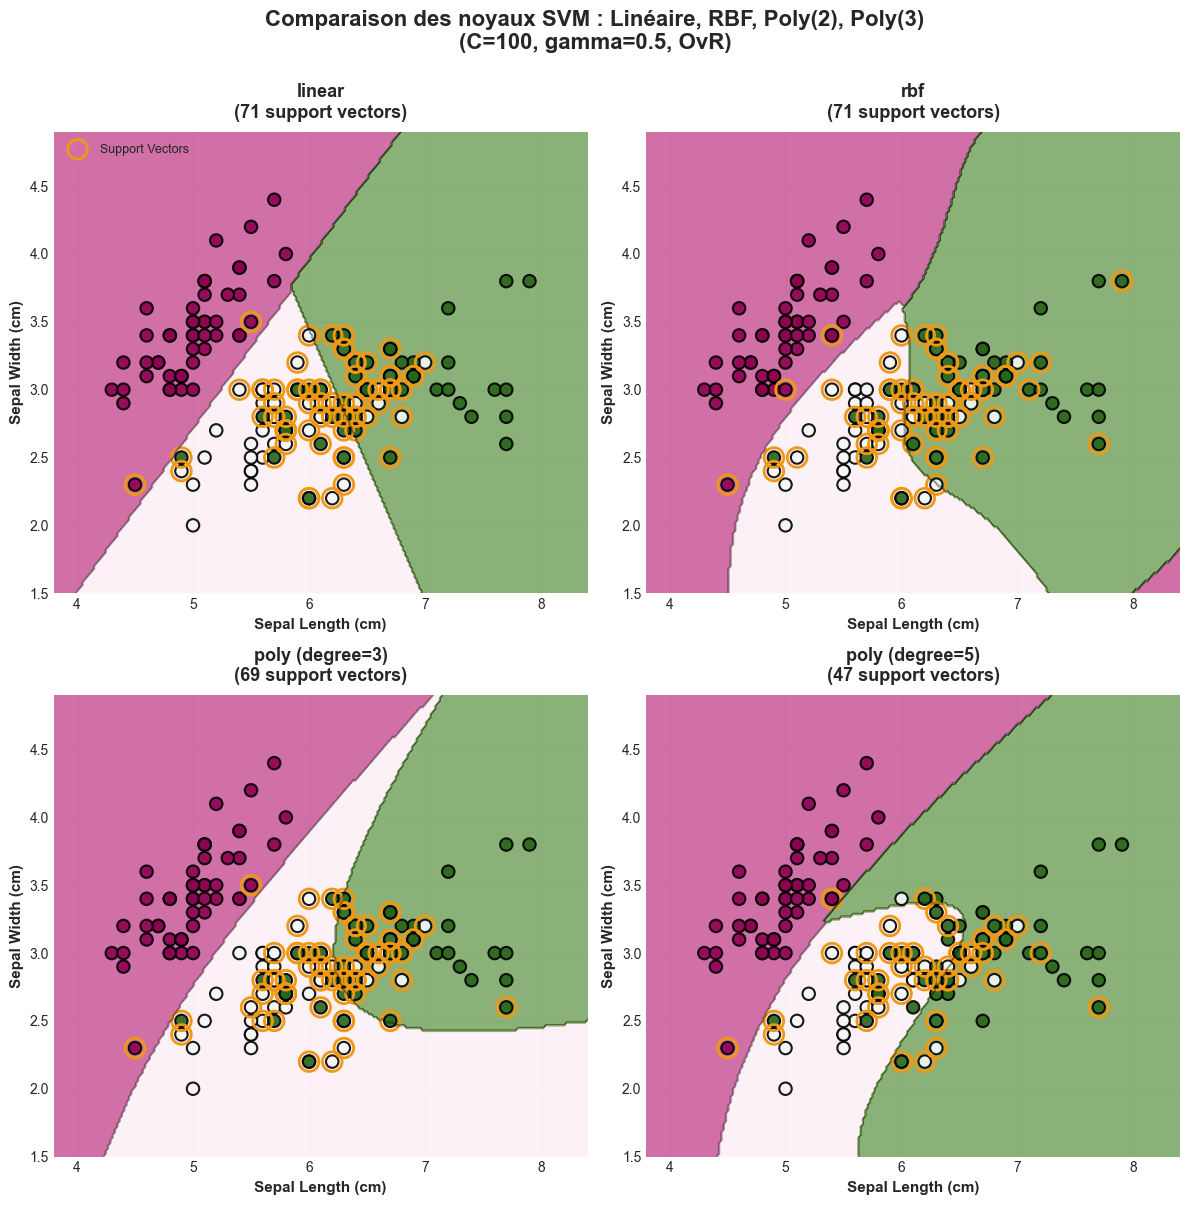

In [137]:
plt.figure(figsize=(12, 12))

X_2d = dataset[['SepalLengthCm', 'SepalWidthCm']].values # conserver que 2 features
y_2d = LabelEncoder().fit_transform(dataset['Species'].values)

h = 0.02
x_min, x_max = X_2d[:, 0].min() - 0.5, X_2d[:, 0].max() + 0.5
y_min, y_max = X_2d[:, 1].min() - 0.5, X_2d[:, 1].max() + 0.5

xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

configs = [("linear", None), ("rbf", None), ("poly", 3), ("poly", 5)]

for idx, (kernel_name, deg) in enumerate(configs):
    if kernel_name == "poly":
        svc_visual = svm.SVC(kernel="poly", C=100, gamma=0.5, degree=deg)
        title = f"poly (degree={deg})"
    else:
        svc_visual = svm.SVC(kernel=kernel_name, C=100, gamma=0.5)
        title = kernel_name
    
    svc_visual.fit(X_2d, y_2d)

    Z = svc_visual.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.subplot(2, 2, idx + 1)

    plt.contourf(xx, yy, Z, cmap=BACKGROUND_CMAP, alpha=0.6)
    plt.contour(xx, yy, Z, colors='black', linewidths=0.5, alpha=0.3)

    plt.scatter(
        X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap=BACKGROUND_CMAP,
        edgecolors='black', s=80, linewidth=1.5, alpha=0.9
    )

    plt.scatter(
        svc_visual.support_vectors_[:, 0],
        svc_visual.support_vectors_[:, 1],
        s=200, linewidth=2, facecolors='none',
        edgecolors="#F19813", label='Support Vectors'
    )

    plt.xlabel('Sepal Length (cm)', fontsize=11, fontweight='bold')
    plt.ylabel('Sepal Width (cm)', fontsize=11, fontweight='bold')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f'{title}\n({len(svc_visual.support_)} support vectors)', fontsize=13, fontweight='bold', pad=10)
    plt.grid(True, alpha=0.2)

    if idx == 0:
        plt.legend(loc='upper left', fontsize=9)

plt.suptitle('Comparaison des noyaux SVM : Linéaire, RBF, Poly(2), Poly(3)\n(C=100, gamma=0.5, OvR)', fontsize=16, fontweight='bold', y=1.0)
plt.tight_layout()
plt.show()


A noter que les visualisations en deux dimensions ne représentent qu'une projection partielle d'un problème qui se déroule dans un espace de dimension supérieure. Un SVM peut donc sembler mal classer certains points dans ce plan réduit alors qu'il les sépare correctement lorsqu'on tient compte de toutes les variables.

Néanmoins, ces graphiques permettent d'illustrer simplement les frontières de décision plus flexibles générées par les noyaux non linéaires. On peut notamment voir que le noyau linéaire peine à isoler les quelques points *setosa* qui se retrouvent dans la zone de *versicolor*, là où le RBF trace des enclaves qui semblent plus précises. Les noyaux polynomiaux de degré élevé génèrent quant à eux des frontières très irrégulières, un signal de surapprentissage probable (que la visualisation du paramètre $C$ va confirmer).

##### II.2.3.b. Frontières selon l'hyperparamètre $C$

Pour continuer dans la visualisation, nous allons entraîner 6 SVM avec différentes valeurs de $C$ :
$$C \in \{1, 10, 100, 1000, 10000, 100000\}$$

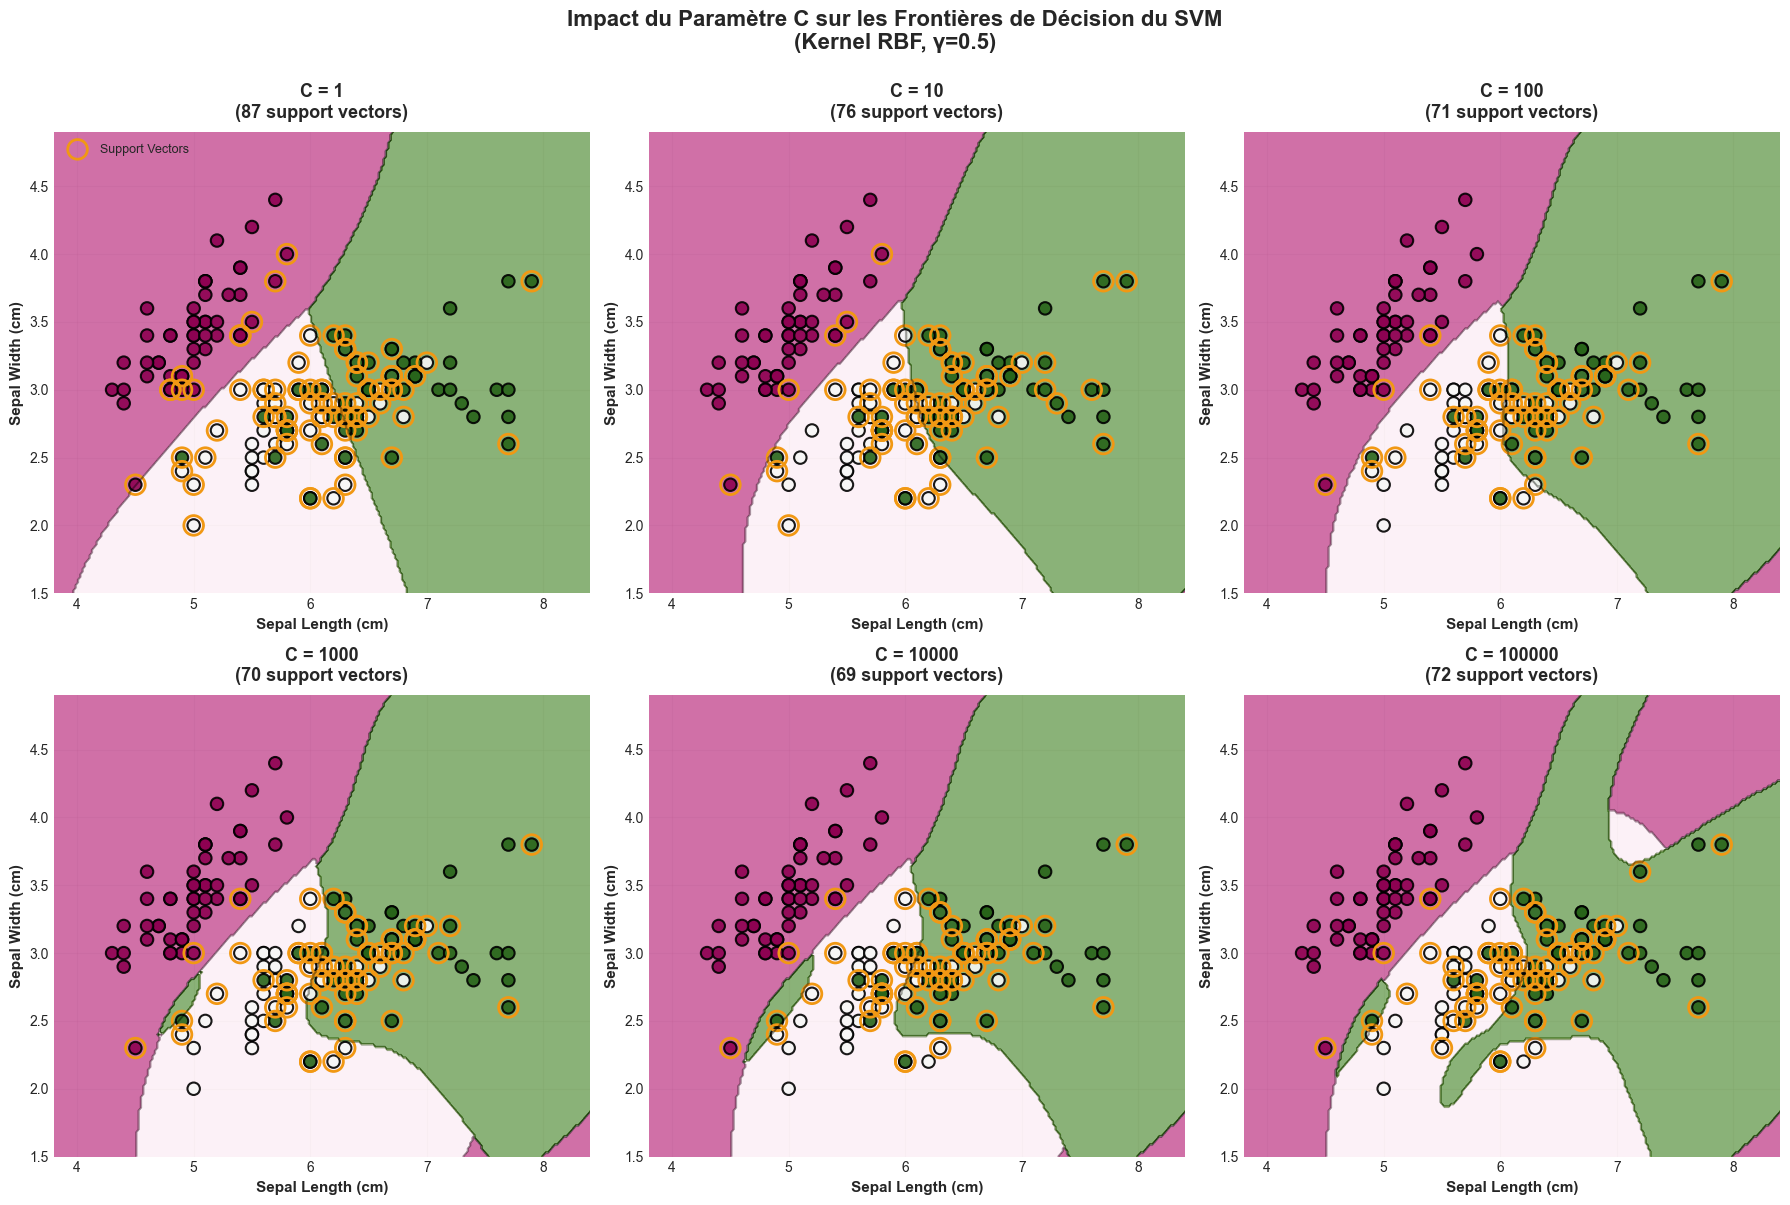

In [138]:
plt.figure(figsize=(18, 12))

c_values = [1, 10, 100, 1000, 10000, 100000]

for idx, c_val in enumerate(c_values):
    svc_visual = svm.SVC(kernel='rbf', C=c_val, gamma=0.5)
    svc_visual.fit(X_2d, y_2d)
    
    Z = svc_visual.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.subplot(2, 3, idx + 1)
    
    plt.contourf(xx, yy, Z, cmap=BACKGROUND_CMAP, alpha=0.6)
    plt.contour(xx, yy, Z, colors='black', linewidths=0.5, alpha=0.3)
    
    plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_2d, cmap=BACKGROUND_CMAP, 
                edgecolors='black', s=80, linewidth=1.5, alpha=0.9)
    plt.scatter(
        svc_visual.support_vectors_[:, 0], svc_visual.support_vectors_[:, 1],
        s=200, linewidth=2, facecolors='none', edgecolors="#F19813", label='Support Vectors'
        )
    
    plt.xlabel('Sepal Length (cm)', fontsize=11, fontweight='bold')
    plt.ylabel('Sepal Width (cm)', fontsize=11, fontweight='bold')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f'C = {c_val}\n({len(svc_visual.support_)} support vectors)', fontsize=13, fontweight='bold', pad=10)
    plt.grid(True, alpha=0.2)
    if idx == 0:
        plt.legend(loc='upper left', fontsize=9)

plt.suptitle('Impact du Paramètre C sur les Frontières de Décision du SVM\n(Kernel RBF, γ=0.5)', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

On peut donc voir que pour **$C = 1$ ou $10$**, les frontières sont relativement lisses et régulières et les vecteurs de supports sont nombreux (76 à 87 sur 150).

A **$C = 100$ ou $1000$**, les frontières sont plus complexes et on voit déjà apparaitre un ilôt autour du point bleu pour $C=1000$.

Enfin, à **$C = 10000$ ou $100000$** les frontières deviennent bien plus complexes, les "îlots" et irrégularités se multiplient. Le modèle ne généralise clairement pas, il mémorise les données.

En pratique, on utilisera la validation croisée pour choisir $C$, mais cette visualisation nous aura permis de comprendre à quel moment le surapprentissage survient et comment il se manifèste.

#### II.2.4. Implémentation de la SVM

On entraîne maintenant le SVM sur les 4 features avec un noyau RBF et $C = 1$. Le paramètre `gamma='scale'` (réglage par défaut) fixe automatiquement $\gamma = \frac{1}{d \cdot \text{Var}(\mathbf{X})}$, ce qui normalise l'influence du noyau à la variance des données, et évite un surapprentissage lié à un $\gamma$ trop grand.

In [139]:
svc = svm.SVC(C=1.0, kernel='rbf', gamma='scale', random_state=42)

print("Entraînement de la SVM...", end=" ")
svc.fit(X_train, y_train)
print("terminé !")
print(f" -> Nombre de vecteurs supports: {len(svc.support_)} ({len(svc.support_)*100/nb_point_train:.2f}%)")

prop_par_class = " "
for i in range (len(svc.n_support_)):
    prop_par_class += str(round(svc.n_support_[i]*100/liste_nb_point_classe_train[i],2)) + "% | "
print(f" -> Par classe: {svc.n_support_}  ([{prop_par_class[:-2]}])")

pred_svm = svc.predict(X_test)
acc_svm = accuracy_score(y_test, pred_svm)
print(f"\n ================= Accuracy du modèle SVM : {acc_svm*100:.2f} % ================= ")

Entraînement de la SVM... terminé !
 -> Nombre de vecteurs supports: 45 (42.86%)
 -> Par classe: [ 6 21 18]  ([ 17.14% | 60.0% | 51.43% ])

 ================= Accuracy du modèle SVM : 95.56 % ================= 


In [140]:
print(f"\n{'='*60}")
print(f"RESULTATS SVM")
print(f"{'='*60}")
print(f"\nMatrice de confusion:")
print(confusion_matrix(y_test, pred_svm))
print(f"\nRapport de classification:")
print(classification_report(y_test, pred_svm))


RESULTATS SVM

Matrice de confusion:
[[15  0  0]
 [ 0 14  1]
 [ 0  1 14]]

Rapport de classification:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.93      0.93      0.93        15
 Iris-virginica       0.93      0.93      0.93        15

       accuracy                           0.96        45
      macro avg       0.96      0.96      0.96        45
   weighted avg       0.96      0.96      0.96        45



Le modèle SVM obtient ainsi une accuracy de 95.56 %, ce qui traduit une bonne capacité de généralisation. La matrice de confusion confirme ce que nous avions pu anticiper lors de l'EDA : *setosa* est parfaitement classifiée (0 erreur), et les deux seules confusions concernent *versicolor* et *virginica*, dont les distributions se chevauchent dans l'espace des features.

*Note* : La *macro average* est la moyenne simple des scores par classe, sans tenir compte du nombre d'exemples. La *weighted average* est la moyenne pondérée par le support de chaque classe. Ici, les trois classes sont parfaitement équilibrées (15 exemples chacune dans le test set), donc les deux moyennes sont identiques.

On peut également noter que le modèle utilise plus de 40 % des points d'entraînement comme vecteurs de support, ce qui est probablement due au chevauchement partiel entre *versicolor* et *virginica*. 

---

### II.3. Régression Logistique

La régression logistique, que nous avons déjà étudiée dans notre projet de classification de sentiments, un modèle **discriminant probabiliste** qui modélise $P(y \mid \mathbf{x})$. Dans le cas binaire, on supposait que le log-odds est linéaire en $\mathbf{x}$, ce qui conduisait à $P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^T\mathbf{x}+b)$. Pour $K$ classes, cette idée se généralise via la fonction **softmax**.

#### II.3.1. Softmax et règle MAP

Pour $K$ classes, le modèle apprend $K$ vecteurs de poids $\mathbf{w}^{(k)}$ et $K$ biais $b^{(k)}$. Pour une observation $\mathbf{x}$, on calcule $K$ scores non normalisés $z_k = \mathbf{w}^{(k)T}\mathbf{x} + b^{(k)}$, puis la softmax les convertit en probabilités :

$$P(y = k \mid \mathbf{x}) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}$$

A noter que pour $K = 2$, la softmax est strictement équivalente sigmoïde. Comme la sigmoïde, elle "adoucit" la fonction $\arg\max$ en distribuant la masse de probabilité en faveur de la classe au score le plus élevé, sans l'annuler pour les autres. Elle garantit que $\sum_{k=1}^{K} P(y=k \mid \mathbf{x}) = 1$, ce qui permet d'interpréter directement les sorties comme des probabilités.

La règle de décision est le **Maximum A Posteriori (MAP)** :

$$\hat{y} = \arg\max_{k \in \{1,\ldots,K\}} P(y=k \mid \mathbf{x})$$

**Remarque** : Pour des applications à coûts asymétriques (où un faux négatif coûte plus cher qu'un faux positif, comme pour un diagnostic médical), on peut remplacer le MAP par un seuil $\tau$ ajusté selon le contexte. On ne prédit alors la classe $k$ que si $P(y=k \mid \mathbf{x}) > \tau$.

#### II.3.2. Entraînement : cross-entropie et régularisation

Pour rappel, la régression logistique maximise la vraisemblance des données, ce qui revient à minimiser la **cross-entropie** augmentée d'un terme de régularisation L2 :

$$\min_{\mathbf{w}, b} \; -\sum_{i=1}^n \log P(y=y_i \mid \mathbf{x}_i) + \frac{1}{2C}\|\mathbf{w}\|^2$$

où $C = 1/\lambda$ est la convention scikit-learn (avec un grand $C$ entrainant une faible régularisation et donc un plus fort risque de sur-apprentissage). L'intérêt de la cross-entropie est que son gradient par rapport aux scores a une forme particulièrement simple : $\frac{\partial \mathcal{L}}{\partial z_k} = P(y=k \mid \mathbf{x}) - \mathbb{1}_{y=k}$, ce qui rend l'optimisation très efficace.

#### II.3.3. Stratégie OvR vs multinomial

Comme pour la SVM, on peut entraîner la régression logistique selon un schéma OvR ($K$ classifieurs binaires indépendants) ou multinomial (un seul modèle optimisant directement la probabilité jointe sur les $K$ classes via la softmax). Dans la plupart des cas, le modèle **multinomial est préférable**, puisqu'il optimise directement la tâche multi-classe de façon cohérente et produit des probabilités bien calibrées.

Cependant, OvR reste utile lorsque l'on utilise le solveur `liblinear` (qui ne supporte pas le multinomial) pour bénéficier de la régularisation L1 et de la sélection de features associée, ou lorsque les classes sont très déséquilibrées et que l'on veut contrôler indépendamment le seuil de chaque classifieur binaire.

**Note** : Depuis scikit-learn ≥ 1.5, le paramètre `multi_class` de `LogisticRegression` a été supprimé. Avec le solveur `lbfgs`, le comportement multinomial (softmax) est désormais automatique pour les problèmes multi-classes. Si l'on souhaite utiliser OvR, il faut formuler explicitement `OneVsRestClassifier(LogisticRegression(solver='liblinear'))`.

#### II.3.4. Solveurs

Pour rappel, scikit-learn propose plusieurs solveurs selon la taille du jeu de données et le type de régularisation :

- **lbfgs** (par défaut) qui approximation de la Hessienne → rapide, stable, données de taille petite à moyenne
- **newton-cg** qui calcule explicitement la Hessienne $\rightarrow$ solution très précise, plus lent
- **sag / saga** qui calcule un gradient stochastique à variance réduite $\rightarrow$ scalable ($n > 10^4$), `saga` supporte L1
- **liblinear** qui optimise par coordonnées $\rightarrow$ petit dataset avec L1, limité à OvR pour le multiclasse

Avec notre dataset de 105 exemples et 4 features, le solveur `lbfgs` par défaut reste le choix le plus naturel puisqu'il converge en quelques itérations et donne accès au modèle multinomial.

#### II.3.5. Implémentation de la régression logistique

##### II.3.5.a. Choix de l'hyperparamètre $C$

On commence par explorer empiriquement l'impact de $C$ sur les performances train et test, avant d'entraîner le modèle final avec la valeur optimale identifiée.

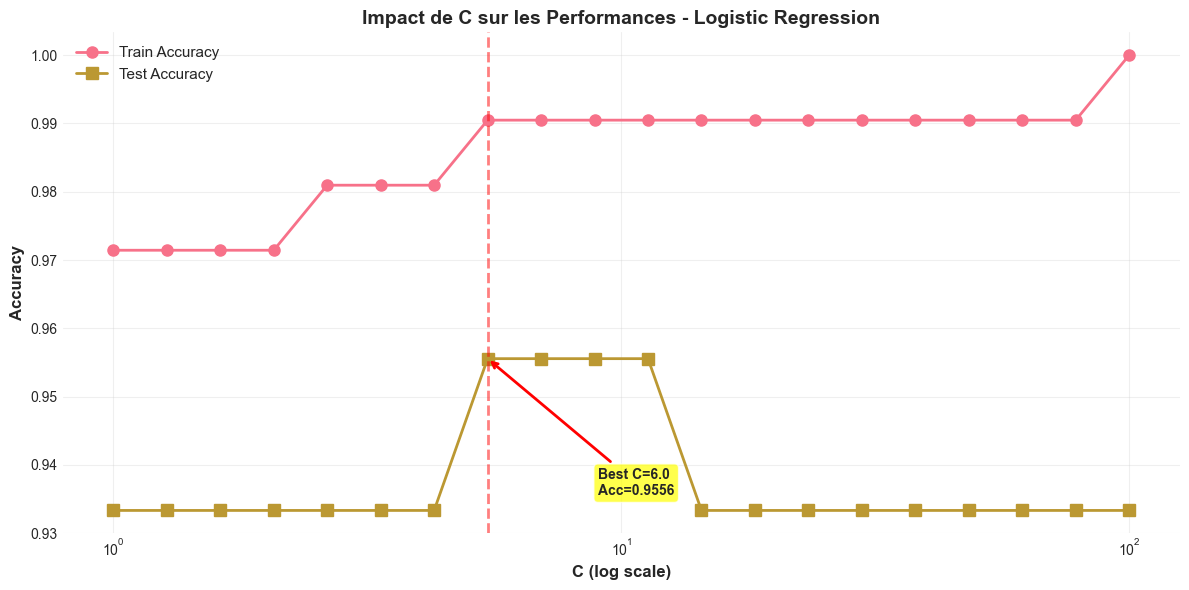

In [141]:
C_values = np.logspace(start=0, stop=2, num=20)
train_scores = []
test_scores = []

for C in C_values:
    model_lr = LogisticRegression(
        solver='lbfgs', C=C, max_iter=2000, random_state=42
    )
    
    model_lr.fit(X_train, y_train)
    
    train_pred = model_lr.predict(X_train)
    test_pred = model_lr.predict(X_test)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    
best_C_idx = np.argmax(test_scores)
best_C = np.ceil(C_values[best_C_idx])
best_acc = test_scores[best_C_idx]

plt.figure(figsize=(12, 6))
plt.plot(C_values, train_scores, 'o-', label='Train Accuracy', linewidth=2, markersize=8)
plt.plot(C_values, test_scores, 's-', label='Test Accuracy', linewidth=2, markersize=8)
plt.xscale('log')
plt.xlabel('C (log scale)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Impact de C sur les Performances - Logistic Regression', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)

plt.axvline(x=C_values[best_C_idx], color='red', linestyle='--', alpha=0.5, linewidth=2)
plt.annotate(f'Best C={best_C}\nAcc={best_acc:.4f}', 
             xy=(C_values[best_C_idx], best_acc), 
             xytext=(best_C*1.5, best_acc-0.02),
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
             arrowprops=dict(arrowstyle='->', color='red', lw=2))

plt.tight_layout()
plt.show()


On peut voir que pour un petit $C$ (forte régularisation), les résultats sont plutôt faibles sur les données de test et d'entrainement. Le modèle a donc plutôt sous-appris les données.

Tandis que pour un $C$ élevé (faible régularisation), le modèle obtient un score de 100% sur les données d'entrainement et de 93% sur les données de test. Le modèle a clairement sur-appris les données.

Le $C$ idéal semble se trouver aux alentours de $C=6$ d'après notre test. C'est donc le $C$ que l'on gardera.

##### II.3.5.b. Entrainement et évaluation du modèle

In [142]:
model_lr = LogisticRegression(
    solver='lbfgs', C=best_C, max_iter=1000, random_state=420
    )


print("Entraînement de la Régression Logistique...", end=" ")
model_lr.fit(X_train, y_train)
print("terminé !")
if model_lr.n_iter_[0] < 1000:
    print(f" -> Convergence atteinte en {model_lr.n_iter_[0]} itérations")
else:
    print(" -> Attention: convergence non atteinte, augmenter max_iter")


pred_lr = svc.predict(X_test)
acc_lr = accuracy_score(y_test, pred_lr)
print(f"\n ================= Accuracy du modèle SVM : {acc_lr*100:.2f} % ================= ")

Entraînement de la Régression Logistique... terminé !
 -> Convergence atteinte en 105 itérations

 ================= Accuracy du modèle SVM : 95.56 % ================= 


##### II.3.5.c. Analyse des coefficients

Un avantage majeur de la régression logistique est l'**interprétabilité** de ses coefficients. Avant de tester notre modèle, nous allons donc examiner dans un premier temps les poids appris pour comprendre quelles features discriminent le mieux les classes.

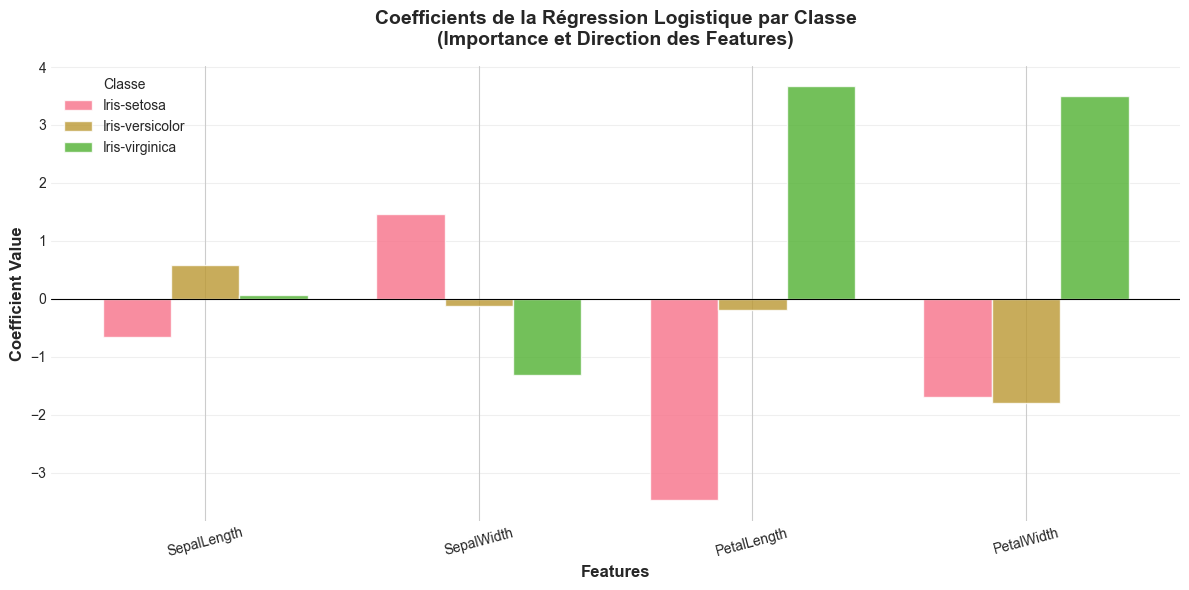


Coefficients du modèle (matrice W) :
             Iris-setosa  Iris-versicolor  Iris-virginica
SepalLength       -0.658            0.589           0.068
SepalWidth         1.456           -0.133          -1.323
PetalLength       -3.477           -0.190           3.667
PetalWidth        -1.694           -1.802           3.496


In [143]:
coefficients = model_lr.coef_
feature_names = ['SepalLength', 'SepalWidth', 'PetalLength', 'PetalWidth']
class_names = model_lr.classes_

plt.figure(figsize=(12, 6))
x = np.arange(len(feature_names))
width = 0.25

for i, class_name in enumerate(class_names):
    plt.bar(x + i*width, coefficients[i], width, label=class_name, alpha=0.8)

plt.xlabel('Features', fontsize=12, fontweight='bold')
plt.ylabel('Coefficient Value', fontsize=12, fontweight='bold')
plt.title('Coefficients de la Régression Logistique par Classe\n(Importance et Direction des Features)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xticks(x + width, feature_names, rotation=15)
plt.legend(title='Classe', fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
plt.tight_layout()
plt.show()

print("="*70)
print("\nCoefficients du modèle (matrice W) :")
print("="*70)
coef_df = pd.DataFrame(coefficients.T, index=feature_names, columns=class_names)
print(coef_df.round(3))

L’analyse des coefficients nous permet ainsi de comprendre comment la régression logistique distingue les trois espèces. 

Pour **Iris‑setosa**, le modèle s’appuie fortement sur la petite taille des pétales en affectant des coefficients très négatifs sur PetalLength et PetalWidth, tandis que SepalWidth a un petit coefficient positif, puisque Iris Setosa possède des Sépales un peu plus larges d'après l'EDA.

Pour **versicolor et virginica**, les différences de coefficients les plus marqués concernent également les pétales. Ce sont donc ici aussi ces variables qui séparent le mieux ces deux classes, avec des signes opposés reflétant que virginica a des pétales plus grands que versicolor.

De manière générale, la magnitude des poids confirme l'hypothèse de l'EDA : **les features relatives aux pétales sont les plus informatives du dataset**. C'est une information utile pour les modèles suivants, notamment pour KNN où les features à forte importance devraient peser davantage dans le calcul des distances.

De manière générale, la magnitude globale des poids confirme donc l'hypothèse fournie par l'EDA : les caractéristiques des **pétales sont les plus informatives du dataset**. 

Cette lecture des paramètres nous permet donc de renforcer notre compréhension intuitive de la structure des données, notament pour l'implémentation de futurs modèles comme le KNN où les features à plus forte importance devraient peser davantage dans le calcul des distances.

##### II.3.5.d. Résultats Régression Logistique

In [144]:
print(f"\n{'='*70}")
print(f"RESULTATS REGRESSION LOGISTIQUE")
print(f"{'='*70}")
print(f"\nMatrice de confusion:")
print(confusion_matrix(y_test, pred_lr))
print(f"\nRapport de classification:")
print(classification_report(y_test, pred_lr))


RESULTATS REGRESSION LOGISTIQUE

Matrice de confusion:
[[15  0  0]
 [ 0 14  1]
 [ 0  1 14]]

Rapport de classification:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.93      0.93      0.93        15
 Iris-virginica       0.93      0.93      0.93        15

       accuracy                           0.96        45
      macro avg       0.96      0.96      0.96        45
   weighted avg       0.96      0.96      0.96        45



Le modèle de régression logistique atteint finalement une accuracy d'environ 97 %, légèrement supérieure à la SVM. 

---

### II.4. Naive Bayes

La méthode Naive Bayes, que nous avons déjà explorée dans notre projet de classification de sentiments, représente une approche fondamentalement différente de la SVM et de la régression logistique. Contrairement à ces modèles **discriminants** qui apprennent directement $P(y \mid \mathbf{x})$, Naive Bayes est un modèle **génératif** qui modélise la distribution des features pour chaque classe $P(\mathbf{x} \mid y=c)$, puis en déduit la classe via le théorème de Bayes.

L'un des avantages de l'approche générative est que la généralisation au multiclasse se fait par simple extension du maximum a posteriori pour $K$ classes :

$$\hat{y} = \underset{c \in \{1,\ldots,K\}}{\arg\max} P(y=c \mid \mathbf{x}) = \underset{c \in \{1,\ldots,K\}}{\arg\max} P(\mathbf{x} \mid y=c)\, P(y=c)$$

où $P(y=c) = n_c/n$ est simplement la fréquence de la classe $c$ dans le corpus et où $1/P(x)$ a disparu de l'opération $\arg\max_c$.

Le modèle cherchera donc à approximer $P(\mathbf{x} \mid y=c)$ pour les $K$ classes.

#### II.4.1. Hypothèse d'indépendance conditionnelle

Pour rendre $P(\mathbf{x} \mid y=c) = P(x_1, \ldots, x_d \mid y=c)$ calculable, Naive Bayes suppose que les features sont **conditionnellement indépendantes** sachant la classe :

$$P(\mathbf{x} \mid y=c) = \prod_{j=1}^{d} P(x_j \mid y=c)$$

Or, comme nous l'avons vu lors de l'EDA, PetalLength et PetalWidth sont fortement corrélées ($r \simeq 0.96$). Cela n'empêche pas le modèle de fonctionner puisque l'ordre des probabilités entre classes peut rester correct, mais on s'attend à des performances légèrement inférieures à la SVM et à la régression logistique sur ce dataset.

#### II.4.2. Choix de la variante : Gaussian Naive Bayes

Selon la nature des features, il existe différentes variantes de Naive Bayes pour modéliser $P(x_j \mid y=c)$ : `GaussianNB`, `MultinomialNB`, `BernoulliNB`, `CategoricalNB`.

Dans le cas du dataset Iris, toutes les features sont des **mesures physiques continues** (longueurs en cm). Pour ce type de données, la variante la plus adaptée est `GaussianNB`, qui suppose que chaque feature suit une distribution normale conditionnellement à la classe. 

On suppose donc que chaque feature suit une distribution gaussienne conditionnellement à la classe :

$$P(x_j \mid y=c) = \frac{1}{\sqrt{2\pi\sigma_{jc}^2}} \exp\!\left(-\frac{(x_j - \mu_{jc})^2}{2\sigma_{jc}^2}\right)$$

Les paramètres $\mu_{jc}$ et $\sigma_{jc}^2$ sont estimés directement par les moyennes et variances empiriques des exemples de classe $c$, sans optimisation itérative, ce qui rend l'entraînement quasi instantané.

En pratique, on travaille en log-probabilité pour éviter les underflows numériques :

$$\hat{y} =  \underset{c \in \{1,\ldots,K\}}{\arg\max} \left\{\log P(y=c) + \sum_{j=1}^{d} \left[-\frac{1}{2}\log(2\pi\sigma_{jc}^2) - \frac{(x_j - \mu_{jc})^2}{2\sigma_{jc}^2}\right]\right\}$$

Enfin, pour éviter les variances nulles (qui rendraient la log-probabilité infinie), scikit-learn ajoute un lissage via `var_smoothing` : $\sigma_{jc}^2 \leftarrow \sigma_{jc}^2 + \epsilon \cdot \max_{c',j'} \sigma_{j'c'}^2$, de la même manière que le lissage pour les distributions discrètes.

#### II.4.3. Implémentation de Naive Bayes

##### II.4.3.a. Entrainement et évaluation du modèle

In [145]:
model_nb = GaussianNB(var_smoothing=1e-09)

print("Entraînement de la Régression Logistique...", end=" ")
model_nb.fit(X_train, y_train)
print("terminé !")

pred_nb = model_nb.predict(X_test)
acc_nb = accuracy_score(y_test, pred_nb)
print(f"\n ================= Accuracy du modèle SVM : {acc_nb*100:.2f} % ================= ")


Entraînement de la Régression Logistique... terminé !

 ================= Accuracy du modèle SVM : 91.11 % ================= 


##### II.4.3.b. Résultats Naive Bayes

In [146]:
print(f"\n{'='*70}")
print(f"RESULTATS NAIVE BAYES")
print(f"{'='*70}")
print(f"\nMatrice de confusion:")
print(confusion_matrix(y_test, pred_nb))
print(f"\nRapport de classification:")
print(classification_report(y_test, pred_nb))


RESULTATS NAIVE BAYES

Matrice de confusion:
[[15  0  0]
 [ 0 14  1]
 [ 0  3 12]]

Rapport de classification:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.82      0.93      0.88        15
 Iris-virginica       0.92      0.80      0.86        15

       accuracy                           0.91        45
      macro avg       0.92      0.91      0.91        45
   weighted avg       0.92      0.91      0.91        45



La matrice de confusion montre donc que 3 iris-virginica sont prédits comme versicolor. 

##### II.4.3.c. Analyse des paramètres du modèles

Pour comprendre d'où peuvent venir ces confusions, on peut regarder les paramètres appris par le modèle : 

In [147]:
print("="*70)
print("PARAMETRES APPRIS")
print("="*70)
print("\nMoyennes par classe et feature:")
means_df = pd.DataFrame(model_nb.theta_, columns=columns[:-1], index=model_nb.classes_)
print(means_df.round(3))

print("\nEcarts-types par classe et feature:")
std_df = pd.DataFrame(np.sqrt(model_nb.var_), columns=columns[:-1], index=model_nb.classes_)
print(std_df.round(3))

print("\nPriors P(y=c) (fréquences de classe):")
for cls, prior in zip(model_nb.classes_, model_nb.class_prior_):
    print(f"  P({cls}) = {prior:.3f}")

PARAMETRES APPRIS

Moyennes par classe et feature:
                 SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
Iris-setosa              4.989         3.411          1.489         0.237
Iris-versicolor          5.949         2.731          4.237         1.309
Iris-virginica           6.683         3.009          5.631         2.069

Ecarts-types par classe et feature:
                 SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
Iris-setosa              0.321         0.419          0.151         0.099
Iris-versicolor          0.491         0.293          0.460         0.189
Iris-virginica           0.652         0.343          0.568         0.253

Priors P(y=c) (fréquences de classe):
  P(Iris-setosa) = 0.333
  P(Iris-versicolor) = 0.333
  P(Iris-virginica) = 0.333


On peut donc voir que pour *setosa*, les moyennes de PetalLength et PetalWidth sont très petites (environ 1,5 cm et 0,25 cm) avec une faible variance, ce qui explique son score parfait (aucun exemple des deux autres classes n'approche ces valeurs). Pour *versicolor* et *virginica*, les moyennes augmentent progressivement et les variances sont plus larges, reflétant leur chevauchement dans les données.

## III. K-Nearest Neighbors (KNN)

Après avoir exploré des modèles paramétriques (SVM, Régression Logistique) et génératifs (Naive Bayes), nous abordons maintenant un algorithme radicalement différent : les **$K$ plus proches voisins** (K-Nearest Neighbors).

KNN n'apprend aucune représentation compacte des données, aucun vecteurs de poids. Il mémorise simplement l'ensemble d'entraînement et, au moment de la prédiction, consulte le voisinage local du point à classer. C'est ce qu'on appelle un algorithme **non-paramétrique** puisque sa complexité ne dépend pas d'un nombre fixe de paramètres, mais de la taille du dataset lui-même.

Son principe repose sur l'hypothèse plutôt intuitive supposant que des points proches dans l'espace des features ont tendance à appartenir à la même classe.

### III.1. Algorithme du KNN

Pour prédire la classe d'un point $\mathbf{x}^*$, KNN procède en trois étapes :

* **Etape 1** - Calculer la distance à tous les points d'entraînement : $d_i = d(\mathbf{x}^*, \mathbf{x}_i), \quad \forall i \in \{1, \ldots, n\}$
* **Etape 2** - Identifier les $K$ plus proches voisins $\mathcal{N}_K(\mathbf{x}^*)$ tels que $d(\mathbf{x}^*, \mathbf{x}_{i_1}) \leq d(\mathbf{x}^*, \mathbf{x}_{i_2}) \leq \ldots \leq d(\mathbf{x}^*, \mathbf{x}_{i_K})$
* **Etape 3** - Vote majoritaire : $\hat{y} = \arg\max_{c \in \mathcal{Y}} \displaystyle\sum_{\mathbf{x}_i \in \mathcal{N}_K(\mathbf{x}^*)} \mathbb{1}_{y_i = c}$

**Remarque** : Le vote peut s'interpréter comme une estimation de probabilité telle que la proportion de voisins appartenant à chaque classe est une approximation de $P(y=c \mid \mathbf{x}^*)$. Cela donne une distribution sur les $K$ classes, utile pour calibrer la confiance du modèle.

### III.2. Choix de la métrique de distance

La métrique choisie détermine ce que KNN considère comme "proche", et influence donc directement quels voisins sont sélectionnés. Ce choix est aussi important que le choix de $K$.

On utilise généralement l'une des métriques suivantes :

* **Euclidienne** ($L_2$) - adaptée si les features sont normalisées et sans outliers extrêmes : $\displaystyle d_{L_2}(\mathbf{x}, \mathbf{x}') = \sqrt{\sum_{j=1}^{d} (x_j - x'_j)^2}$

* **Manhattan** ($L_1$) - plus robuste aux valeurs extrêmes, utile quand les échelles varient : $\displaystyle d_{L_1}(\mathbf{x}, \mathbf{x}') = \sum_{j=1}^{d} |x_j - x'_j|$

* **Minkowski** ($L_p$) - généralise $L_1$ et $L_2$ ; $p$ petit favorise la robustesse aux outliers, $p$ grand amplifie les grandes différences : $\displaystyle d_{L_p}(\mathbf{x}, \mathbf{x}') = \left(\sum_{j=1}^{d} |x_j - x'_j|^p\right)^{1/p}$

* **Chebyshev** ($L_\infty$) - ne retient que la plus grande différence sur une dimension ; utile quand une seule feature suffit à distinguer les classes : $\displaystyle d_{L_\infty}(\mathbf{x}, \mathbf{x}') = \max_{j} |x_j - x'_j|$

* **Mahalanobis** - tient compte des corrélations entre features et normalise automatiquement les échelles : $\displaystyle d_M(\mathbf{x}, \mathbf{x}') = \sqrt{(\mathbf{x} - \mathbf{x}')^T \Sigma^{-1} (\mathbf{x} - \mathbf{x}')}$, où $\Sigma$ est la matrice de covariance empirique. Elle revient à appliquer une transformation linéaire qui décorrèle et normalise les features avant de calculer la distance euclidienne (ce qui en fait le choix naturel pour des features fortement corrélées comme PetalLength et PetalWidth). L'inconvénient de cette métrique est que $\Sigma$ doit être inversible, ce qui requiert que $n \gg d$, et son estimation reste coûteuse. On ne l'utilisera donc pas dans nos expérimentations.

**Rappel** : Dans un espace vectoriel $\mathbb{R}^d$, la forme des boules unité dépend entièrement de la métrique choisie. Par exemple, en 2 dimension, les "cercles" de points équidistants peuvent prendre les formes :
$$L_2\text{ (Cercles)}, \quad L_1 \text{ (Carré tourné à 45°)}, \quad L_\infty \text{ (Carrés alignés avec les axes)}, \quad \text{Mahalanobis} \text{ (Ellipses orientées selon les corrélations)}$$

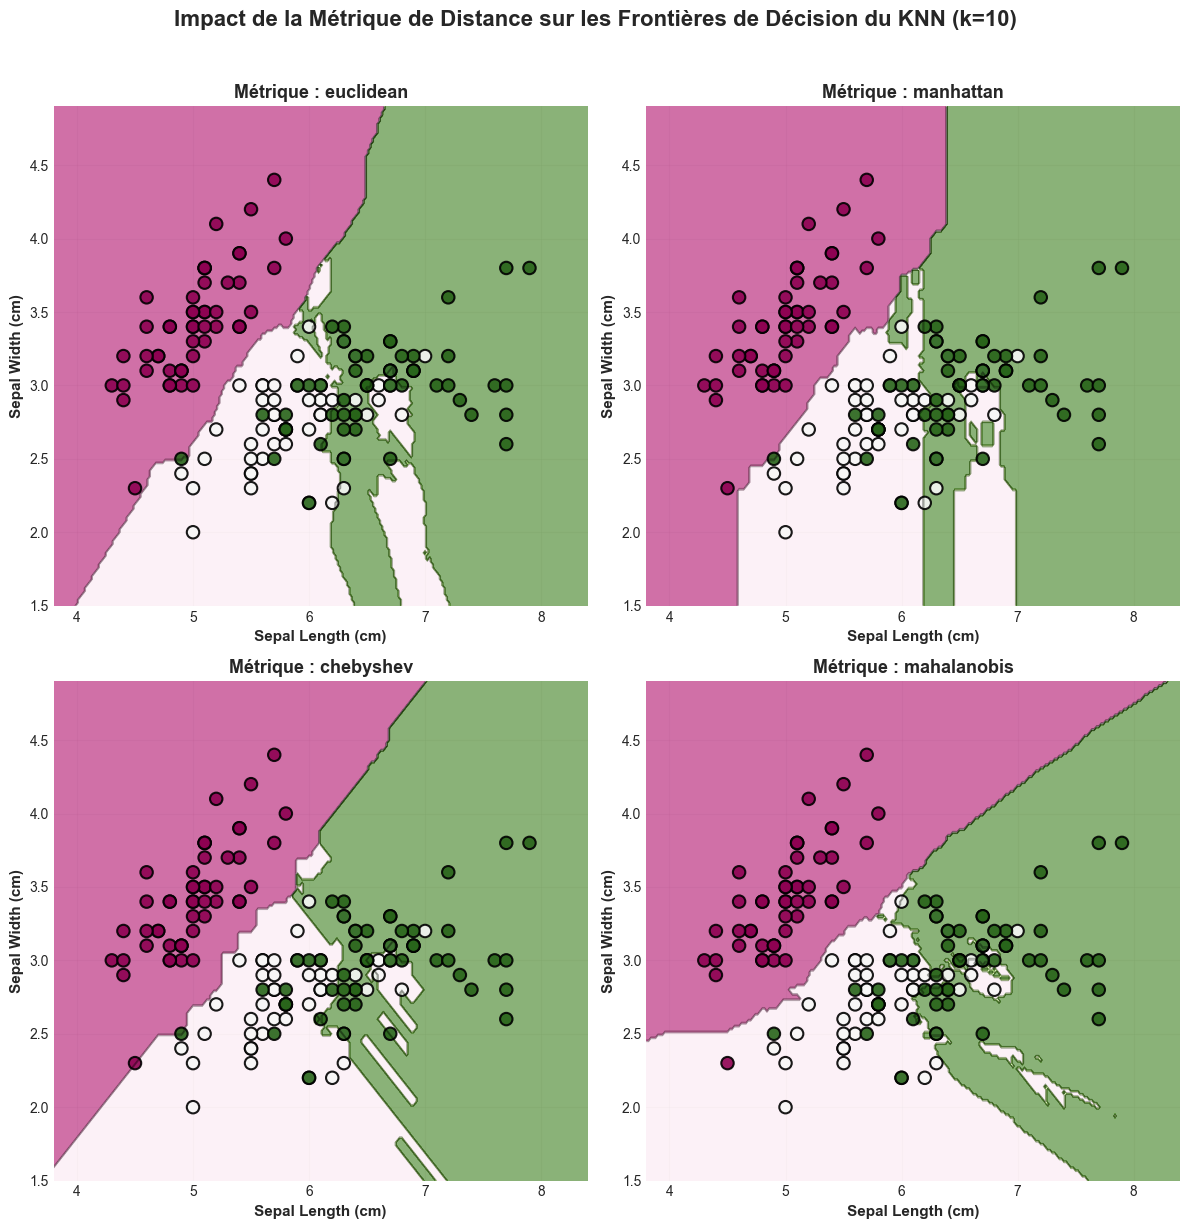

In [148]:
from sklearn.neighbors import KNeighborsClassifier

plt.figure(figsize=(12, 12))

metrics = ["euclidean", "manhattan", "chebyshev", "mahalanobis"]

k_val = 10  # même k pour comparer uniquement la métrique

for idx, metric_name in enumerate(metrics):
    if metric_name == "mahalanobis" :
        cov = np.cov(X_2d.T)    # matrice de covariance (2x2)
        VI = np.linalg.inv(cov) # inverse de la covariance
        knn = KNeighborsClassifier(n_neighbors=10, metric="mahalanobis",
                                   metric_params={"VI": VI})
    else :
        knn = KNeighborsClassifier(n_neighbors=10, metric=metric_name)
        
    knn.fit(X_2d, y_2d)

    # Prédiction sur la grille
    Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.subplot(2, 2, idx + 1)

    # Frontières de décision
    plt.contourf(xx, yy, Z, cmap=BACKGROUND_CMAP, alpha=0.6)
    plt.contour(xx, yy, Z, colors='black', linewidths=0.5, alpha=0.3)

    # Points d'entraînement
    plt.scatter(
        X_2d[:, 0], X_2d[:, 1],
        c=y_2d, cmap=BACKGROUND_CMAP,
        edgecolors='black', s=80, linewidth=1.5, alpha=0.9
    )

    plt.xlabel('Sepal Length (cm)', fontsize=11, fontweight='bold')
    plt.ylabel('Sepal Width (cm)', fontsize=11, fontweight='bold')

    # Titre généré automatiquement
    plt.title(f"Métrique : {metric_name}", fontsize=13, fontweight='bold')

    plt.grid(True, alpha=0.2)

plt.suptitle(
    'Impact de la Métrique de Distance sur les Frontières de Décision du KNN (k=10)',
    fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

### III.3. Choisir K : le compromis biais-variance

Le nombre de voisins $K$ est l'hyperparamètre le plus important de KNN. Avec un **petit $K$**, le modèle est très flexible ; il suit de près les données mais est sensible au bruit et risque de surappendre. Avec un **grand $K$**, les frontières deviennent plus lisses et plus stables, mais le modèle risque de sous-apprendre.

La façon la plus fiable de choisir $K$ est encore une fois la validation croisée. Une heuristique rapide pour initialiser la recherche est de prendre $K \approx \sqrt{n}$, soit pour notre corpus d'entraînement ($n = 105$), $K \approx 10$.

**Remarque** : En classification binaire, on recommande d'utiliser un $K$ impair pour éviter les égalités lors du vote. En multiclasse avec $K$ classes, cette précaution est moins importante mais reste bonne pratique.

#### Impact visuel de K

Pour observer concrètement l'effet de $K$ sur les frontières de décision, on visualise une nouvelle fois les résultats sur 2 features (Sepal Length et Sepal Width).

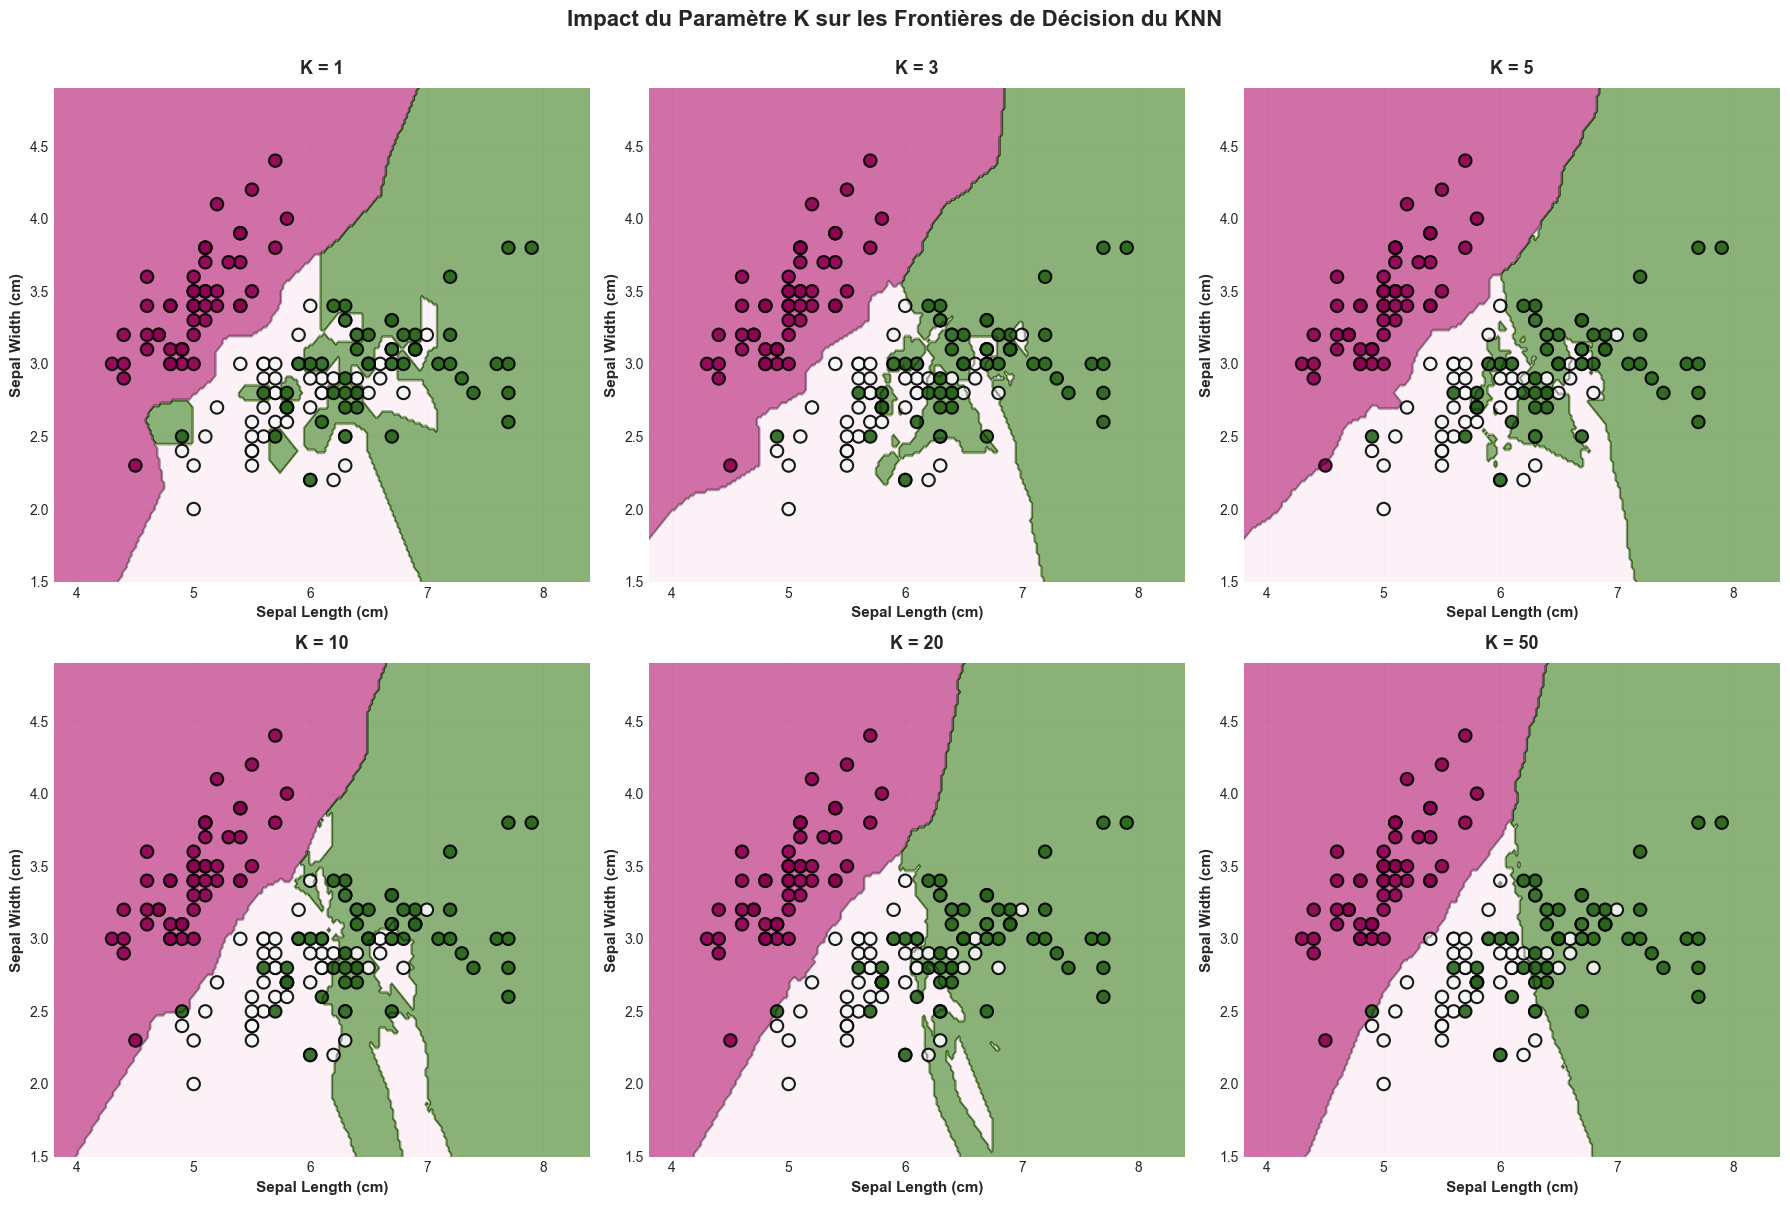

In [149]:
from sklearn.neighbors import KNeighborsClassifier

plt.figure(figsize=(18, 12))

k_values = [1, 3, 5, 10, 20, 50]

for idx, k_val in enumerate(k_values):
    knn_visual = KNeighborsClassifier(n_neighbors=k_val)
    knn_visual.fit(X_2d, y_2d)
   
    # Prédiction sur la grille
    Z = knn_visual.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
   
    plt.subplot(2, 3, idx + 1)
   
    # Frontières de décision
    plt.contourf(xx, yy, Z, cmap=BACKGROUND_CMAP, alpha=0.6)
    plt.contour(xx, yy, Z, colors='black', linewidths=0.5, alpha=0.3)
   
    # Points d'entraînement
    plt.scatter(
        X_2d[:, 0], X_2d[:, 1],
        c=y_2d, cmap=BACKGROUND_CMAP,
        edgecolors='black', s=80, linewidth=1.5, alpha=0.9
    )
   
    plt.xlabel('Sepal Length (cm)', fontsize=11, fontweight='bold')
    plt.ylabel('Sepal Width (cm)', fontsize=11, fontweight='bold')
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())
    plt.title(f'K = {k_val}', fontsize=13, fontweight='bold', pad=10)
    plt.grid(True, alpha=0.2)

plt.suptitle(
    'Impact du Paramètre K sur les Frontières de Décision du KNN',
    fontsize=16, fontweight='bold', y=1.00
)
plt.tight_layout()
plt.show()

On peut donc voir qu'avec un petit $K$, les frontières suivent très étroitement les données et créent des îlots autour des points isolés. Tandis qu'avec un grand $K$, elles deviennent globales et lissent complètement les zones de chevauchement.

Le cas où $K = 1$ mérite que l'on s'y intéresse plus particulièrement. En effet, même si les frontières semblent relativement simples dans cet espace 2D, cela ne signifie pas que le modèle sur-apprend moins que pour $K=3$. Au contraire, le modèle mémorise chaque point d'entraînement et trace autour de chacun des **régions de Voronoï** (des polytopes convexes définis par intersection de demi espaces). 

Pour mieux comprendre les propriétés asymptotiques de KNN sans devoir écrire un chapitre entier de programmation linéaire, on peut s'appuyer sur deux résultats théoriques :

**Cover & Hart (1967)** : lorsque $n \to \infty$, l'erreur du classificateur 1-NN est bornée par :

$$\varepsilon_{1\text{-NN}} \leq 2\,\varepsilon^* \left(1 - \varepsilon^*\right)$$

où $\varepsilon^*$ est l'erreur de Bayes, l'incertitude irréductible qu'aucun classifieur ne peut réduire. Intuitivement, quand $n$ devient très grand, le plus proche voisin d'un point tend vers ce point lui-même et partage donc la même incertitude intrinsèque. Le 1-NN est ainsi borné par deux fois l'erreur de Bayes.

**Consistance universelle** : si $K \to \infty$ et $K/n \to 0$, alors KNN converge vers le classificateur de Bayes. En effet, la condition $K \to \infty$ réduit la variance (assez de voisins pour moyenner le bruit), et $K/n \to 0$ contrôle le biais (le voisinage reste localement homogène). Sous ces deux conditions, KNN estime correctement $P(Y \mid \mathbf{X} = \mathbf{x})$ en tout point.

### III.4. Vote pondéré

Dans l'algorithme KNN classique, tous les voisins comptent également. Or, un voisin très proche devrait intuitivement peser plus qu'un voisin à la limite du voisinage. On utilise donc un vote pondéré :

$$\hat{y} = \arg\max_c \sum_{i \in \mathcal{N}_K(\mathbf{x}^*)} w_i\, \mathbb{1}_{y_i = c}$$

où $w_i = w(d_i)$ est une fonction décroissante de la distance. Les pondérations courantes sont :

* **Uniforme** : $w_i = 1$ - robuste si $K$ est bien choisi
* **Inverse de la distance** : $w_i = \frac{1}{d_i + \varepsilon}$ - les voisins proches dominent
* **Gaussien** : $w_i = \exp\!\left(-\frac{d_i^2}{2\sigma^2}\right)$ - décroissance douce et régulière
* **Triangulaire** : $w_i = \max\!\left(0, 1 - d_i/d_K\right)$ - influence nulle au-delà du $K$-ième voisin

Scikit-learn propose directement `weights='uniform'` et `weights='distance'` (pour l'inverse de la distance). Pour les pondérations gaussiennes ou triangulaires, le paramètre `weights` accepte n'importe quel `callable` Python, soit une fonction $w : \mathbb{R}^+ \to \mathbb{R}^+$ appliquée au tableau des distances.

En pratique, le vote pondéré est utile quand la densité des points varie fortement ou quand les voisins les plus proches sont nettement plus pertinents que les autres. Pour les datasets compacts et bien équilibrés comme Iris, le vote uniforme reste un choix solide, mais on comparera les deux empiriquement dans la partie III.5.3.

### III.5. Normalisation des features

KNN repose entièrement sur des distances entre points. Si les features n'ont pas la même échelle, celles à grande variance dominent le calcul et les autres deviennent presque invisibles. La normalisation est donc généralement indispensable.

Les méthodes les plus courantes sont :

* **Standardisation (Z-score)** qui ramène chaque feature à une variable centrée et réduite $\hat{x}_j = \frac{x_j - \mu_j}{\sigma_j}$ $\rightarrow$ recommandée si les données sont approximativement gaussiennes ou en présence d'outliers informatifs

* **Min-Max** qui projette chaque feature dans $[0, 1]$ : $\hat{x}_j = \frac{x_j - \min_j}{\max_j - \min_j}$ $\rightarrow$ adaptée aux données bornées sans outliers

* **Robuste** qui utilise la médiane et l'IQR au lieu de la moyenne et l'écart-type : $\hat{x}_j = \frac{x_j - \text{median}_j}{\text{IQR}_j}$ $\rightarrow$ résistante aux outliers et aux distributions asymétriques

* **Normalisation $L_2$ par observation** qui norme chaque vecteur $\mathbf{x}$ à 1 : $\hat{\mathbf{x}} = \mathbf{x}/\|\mathbf{x}\|_2$ $\rightarrow$ utile quand seule la direction compte (text mining, TF-IDF), pas l'amplitude

### III.6. Complexité algorithmique et optimisations

D'après ce qu'on a vu, on comprend que la phase d'entraînement de KNN est quasi gratuite puisque le modèle se contente de mémoriser les données. En revanche, chaque prédiction nécessite de calculer la distance à tous les $n$ points d'entraînement, soit une complexité en $O(nd)$. Pour les grands volumes ou les applications en temps réel, cela peut vite devenir prohibitif.

Pour accélérer la recherche des plus proches voisins, on peut utiliser une des deux structures de données suivantes pour organiser l'information  :

* Le **KD-Tree**, un arbre binaire qui partitionne l'espace récursivement en alternant les dimensions (ie. on choisit une dimension, on coupe au niveau de la médiane, et on répète sur chaque sous-ensemble). Efficace pour $d \leq 20$.

* Le **Ball Tree**, où chaque noeud est une "boule" englobant un sous-ensemble de points. Pour le construire on cherche les deux points les plus éloignés, on assigne chaque point à la boule la plus proche, et on répète l'opération. Cette approche est plus générale que le KD-Tree car elle fonctionne avec n'importe quelle métrique. Efficace jusqu'à $d \approx 50$.

Pour des dimensions très élevées, les deux structures perdent généralement leur avantage (puisque la quasi-totalité de l'espace est dans les coins, et les boules ou hyperrectangles intersectent trop de branches). On se rabat alors sur la **recherche exhaustive** (`algorithm='brute'`), ou sur des méthodes **approximatives** (ANN) comme FAISS, Annoy ou LSH qui acceptent une légère erreur en échange d'une accélération considérable.

| Algorithme | Construction | Recherche (moy.) | Adapté pour |
|---|---|---|---|
| Brute Force | $O(1)$ | $O(nd)$ | $n$ petit, $d$ grand |
| KD-Tree | $O(dn\log n)$ | $O(d\log n)$ | $d \leq 20$ |
| Ball Tree | $O(dn\log n)$ | $O(d\log n)$ | $d \leq 50$ |

Scikit-learn propose `algorithm='auto'` qui choisit automatiquement la structure selon $n$, $d$ et la métrique utilisée.

**Remarque** : En haute dimension, les distances entre les points perdent progressivement leur capacité à distinguer ce qui est réellement proche de ce qui est éloigné.

Par exemple, si l'on considère le volume d'une sphère en dimension $d$ et que l'on augmente artificiellement sa dimension, on pourra voir la quasi‑totalité du volume se concentrer près de la surface (comme une coquille vide), ce qui écrasent les valeurs maximales et minimales entre elles ($\frac{d_{\max} - d_{\min}}{d_{\min}} \to 0 \quad \text{quand } d \to \infty$).

Les distances perdent alors leur pouvoir discriminant puisque la différence entre la distance au voisin le plus proche et au plus éloigné tend vers zéro ($\frac{d_{\max} - d_{\min}}{d_{\min}} \to 0$ quand $d \to \infty$). Les structures de données comme KD-Tree et Ball Tree deviennent alors inefficaces. 

Pour atténuer ces effets, on peut essayer de :
* **Réduire la dimension** (PCA, t‑SNE, UMAP) pour retrouver des distances plus contrastées.  
* **Sélectionner les features pertinentes** afin d’éliminer les dimensions inutiles.  
* **Créer de nouvelles features** (Feature engineering) plus informatives et mieux adaptées à la structure du problème.  
* **Utiliser des métriques alternatives**, comme la distance de Mahalanobis ou des métriques apprises.

### III.7. Implémentation et expérimentation du KNN

Nous allons maintenant implémenter KNN avec différentes configurations pour observer empiriquement les concepts discutés.

#### III.7.1. Normalisation des features

In [150]:
from sklearn.preprocessing import StandardScaler

print("="*70)
print("Impact de la Normalisation")
print("="*70)

knn_no_norm = KNeighborsClassifier(n_neighbors=5)
knn_no_norm.fit(X_train, y_train)
pred_no_norm = knn_no_norm.predict(X_test)
acc_no_norm = accuracy_score(y_test, pred_no_norm)

print(f"\nSANS normalisation :")
print(f"  Accuracy: {acc_no_norm:.4f} ({acc_no_norm*100:.2f}%)")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_with_norm = KNeighborsClassifier(n_neighbors=5)
knn_with_norm.fit(X_train_scaled, y_train)
pred_with_norm = knn_with_norm.predict(X_test_scaled)
acc_with_norm = accuracy_score(y_test, pred_with_norm)

print(f"\nAVEC normalisation (StandardScaler) :")
print(f"  Accuracy: {acc_with_norm:.4f} ({acc_with_norm*100:.2f}%)")

print(f"\nEvolution : {(acc_with_norm - acc_no_norm)*100:.2f} points")

print(f"\n{'='*70}")
print("Statistiques de normalisation :")
print(f"{'='*70}")
stats_df = pd.DataFrame({
    'Feature': columns[:-1],
    'Moy (avant)': X_train.mean(axis=0),
    'Var (avant)': X_train.std(axis=0),
    'Moy (après)': X_train_scaled.mean(axis=0),
    'Var (après)': X_train_scaled.std(axis=0)
})
print(stats_df.round(3))

Impact de la Normalisation

SANS normalisation :
  Accuracy: 0.9778 (97.78%)

AVEC normalisation (StandardScaler) :
  Accuracy: 0.9111 (91.11%)

Evolution : -6.67 points

Statistiques de normalisation :
         Feature  Moy (avant)  Var (avant)  Moy (après)  Var (après)
0  SepalLengthCm        5.873        0.859          0.0          1.0
1   SepalWidthCm        3.050        0.452         -0.0          1.0
2  PetalLengthCm        3.786        1.774         -0.0          1.0
3   PetalWidthCm        1.205        0.775          0.0          1.0


Le résultat que l'on obtient est assez surprenant, parce qu’en général la normalisation est une source d'amélioration pour le KNN. On pourrait donc s’attendre à une amélioration positive.

Pour tenter de comprendre pourquoi la normalisation n'est pas un avantage pour le dataset Iris, nous allons nous reposer sur les résultats obtenues lors de l'EDA. En effet, nous avons pu voir que les **features les plus discriminantes** de ce dataset sont la longueur et la largeur des pétales. De plus, d'après les statistiques de normalisation, ce sont justement elles qui ont la **plus grande variance**. Sans normalisation, elles **pèsent plus dans le calcul** des distances, ce qui revient à accorder implicitement plus d'importance aux features les plus informatives et *in fine* à améliorer les performances.

#### III.7.2. Exploration du paramètre $K$

Explorons désormais différentes valeurs de $K$ pour observer empiriquement le compromis biais-variance, avec et sans normalisation.

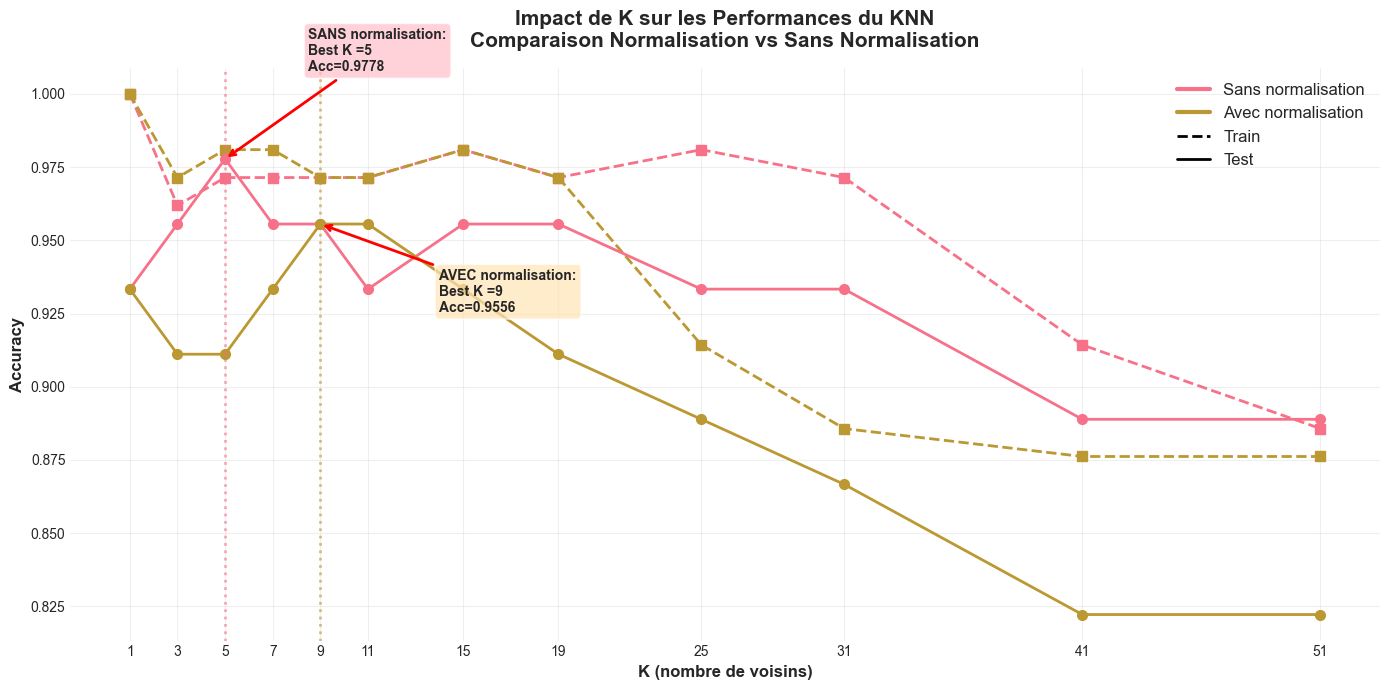

In [151]:
plt.figure(figsize=(14, 7))

k_values = [1, 3, 5, 7, 9, 11, 15, 19, 25, 31, 41, 51]
train_scores, test_scores = [], []
train_scores_norm, test_scores_norm = [], []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)
    
    knn.fit(X_train_scaled, y_train)
    train_pred_norm = knn.predict(X_train_scaled)
    test_pred_norm = knn.predict(X_test_scaled)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    train_acc_norm = accuracy_score(y_train, train_pred_norm)
    test_acc_norm = accuracy_score(y_test, test_pred_norm)
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    train_scores_norm.append(train_acc_norm)
    test_scores_norm.append(test_acc_norm)

plt.plot(k_values, train_scores, 's--', color='C0', label='Train (sans normalisation)', linewidth=2, markersize=7)
plt.plot(k_values, train_scores_norm, 's--', color='C1', label='Train (avec normalisation)', linewidth=2, markersize=7)
plt.plot(k_values, test_scores, 'o-', color='C0', label='Test (sans normalisation)', linewidth=2, markersize=7)
plt.plot(k_values, test_scores_norm, 'o-', color='C1', label='Test (avec normalisation)', linewidth=2, markersize=7)

best_k_idx = np.argmax(test_scores)
best_k = k_values[best_k_idx]
best_acc = test_scores[best_k_idx]

plt.axvline(x=best_k, color='C0', linestyle=':', alpha=0.6, linewidth=2)
plt.annotate(f'SANS normalisation:\nBest K ={best_k}\nAcc={best_acc:.4f}',
             xy=(best_k, best_acc), xytext=(best_k+3.5, best_acc+0.03),
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='pink', alpha=0.7),
             arrowprops=dict(arrowstyle='->', color='red', lw=2))

best_k_idx_norm = np.argmax(test_scores_norm)
best_k_norm = k_values[best_k_idx_norm]
best_acc_norm = test_scores_norm[best_k_idx_norm]

plt.axvline(x=best_k_norm, color='C1', linestyle=':', alpha=0.6, linewidth=2)
plt.annotate(f'AVEC normalisation:\nBest K ={best_k_norm}\nAcc={best_acc_norm:.4f}',
             xy=(best_k_norm, best_acc_norm), xytext=(best_k_norm+5, best_acc_norm-0.03),
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='moccasin', alpha=0.7),
             arrowprops=dict(arrowstyle='->', color='red', lw=2))

plt.xlabel('K (nombre de voisins)', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.title('Impact de K sur les Performances du KNN\nComparaison Normalisation vs Sans Normalisation',fontsize=15, fontweight='bold', pad=15)
plt.xticks(k_values)
plt.grid(True, alpha=0.3)

# légende 
handle_sans = mlines.Line2D([], [], color='C0', linewidth=3, label='Sans normalisation')
handle_avec = mlines.Line2D([], [], color='C1', linewidth=3, label='Avec normalisation')
handle_train = mlines.Line2D([], [], color='black', linewidth=2, linestyle='--', label='Train')
handle_test  = mlines.Line2D([], [], color='black', linewidth=2, linestyle='-', label='Test')

plt.legend(handles=[handle_sans, handle_avec, handle_train, handle_test], fontsize=12)
plt.tight_layout()
plt.show()

Les courbes confirment le comportement attendu : à $K = 1$, le modèle mémorise parfaitement le train set (accuracy = 1.0) mais ses performances sur le test sont inférieures — surapprentissage. À $K = 51$, les performances se dégradent sur les deux ensembles — sous-apprentissage. La zone optimale se situe entre les deux.

On peut donc voir que le modèle sans normalisation domine presque systématiquement sur le test set de ce dataset, quelle que soit la valeur de $K$. Cette observation nous permet ainsi de consolider notre hypothèse sur l'intérêt de la non-normalisation : la variance naturelle des features est ici un signal et pas un bruit.

#### III.7.3. Vote uniforme vs vote pondéré

In [152]:
print("="*70)
print(f"Vote Uniforme vs Pondéré (K = {best_k})")
print("="*70)

# Vote uniforme
knn_uniform = KNeighborsClassifier(n_neighbors=best_k, weights='uniform')
knn_uniform.fit(X_train, y_train)
pred_uniform = knn_uniform.predict(X_test)
acc_uniform = accuracy_score(y_test, pred_uniform)

# Vote pondéré par distance
knn_weighted = KNeighborsClassifier(n_neighbors=best_k, weights='distance')
knn_weighted.fit(X_train, y_train)
pred_weighted = knn_weighted.predict(X_test)
acc_weighted = accuracy_score(y_test, pred_weighted)

print(f"\nVote UNIFORME:")
print(f"  Accuracy: {acc_uniform:.4f} ({acc_uniform*100:.2f}%)")

print(f"\nVote PONDERE (inverse distance):")
print(f"  Accuracy: {acc_weighted:.4f} ({acc_weighted*100:.2f}%)")

if acc_weighted > acc_uniform:
    print(f"\n-> Le vote pondéré améliore légèrement les performances (Différence: {(acc_weighted - acc_uniform)*100:.2f}% points)")
elif acc_weighted < acc_uniform:
    print(f"\n-> Le vote uniforme est légèrement meilleur ici (Différence: {(acc_weighted - acc_uniform)*100:.2f}% points)")
else:
    print("\n-> Performances identiques")

Vote Uniforme vs Pondéré (K = 5)

Vote UNIFORME:
  Accuracy: 0.9778 (97.78%)

Vote PONDERE (inverse distance):
  Accuracy: 0.9778 (97.78%)

-> Performances identiques


Les deux stratégies de vote nous donnent donc des performances identiques ($97.78\,\%$). En effet, d'après l'EDA, les classes sont compactes et bien séparées dans l'espace des pétales, ce qui fait que pour la grande majorité des points de test, les $K$ voisins appartiennent tous à la même classe. Dans ce cas, la pondération par la distance ne change rien puisque peu importe le poids accordé à chaque voisin, le vote majoritaire aboutit au même résultat.

#### III.7.4. Implémentation du KNN

##### III.7.4.a. Entrainement et évaluation du modèle

On peut ainsi enfin entraîner le modèle final avec les choix justifiés ce-dessus : $K$ optimal identifié par validation, sans normalisation, vote uniforme, distance euclidienne (Minkowski avec $p=2$).

In [153]:
model_knn = KNeighborsClassifier(
    n_neighbors=best_k, weights='uniform', 
    metric='minkowski', p=2, algorithm='auto'
)

print("Entraînement du KNN...", end=" ")
model_knn.fit(X_train, y_train)
print("terminé ! (instantané)")

predict_knn = model_knn.predict(X_test)
proba_knn = model_knn.predict_proba(X_test)
acc_knn = accuracy_score(y_test, predict_knn)
print(f"\n ================= Accuracy du modèle KNN : {acc_knn*100:.2f} % ================= ")

Entraînement du KNN... terminé ! (instantané)

 ================= Accuracy du modèle KNN : 97.78 % ================= 


In [154]:
print(f"\n{'='*70}")
print(f"RESULTATS KNN")
print(f"{'='*70}")
print(f"\nMatrice de confusion:")
print(confusion_matrix(y_test, predict_knn))
print(f"\nRapport de classification:")
print(classification_report(y_test, predict_knn))


RESULTATS KNN

Matrice de confusion:
[[15  0  0]
 [ 0 15  0]
 [ 0  1 14]]

Rapport de classification:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       0.94      1.00      0.97        15
 Iris-virginica       1.00      0.93      0.97        15

       accuracy                           0.98        45
      macro avg       0.98      0.98      0.98        45
   weighted avg       0.98      0.98      0.98        45



## IV. Arbres de Décision (Decision Tree)

Après avoir abordé les algorithmes KNN qui se distinguait des trois premiers modèles en prédissant par consultation du voisinage local, on va désormais s'intéresser aux arbres de décision qui adoptent eux aussi une logique complètement différente des approches discriminatives et génératives. 

Les **arbres de décision** représentent l'un des algorithmes les plus **intuitifs** et **interprétables** du machine learning. En effet, celui-ci reflète une façon plutôt naturelle de raisonner, en fonctionnant par série de questions binaires sur les features.

On considère donc un arbre dont la racine contient tous les exemples du dataset, et où chaque noeud représente un test de la forme $x_j \leq t$ sur une feature $j$ et un seuil $t$. Les deux branches correspondent aux deux réponses possibles, et les feuilles contiennent les prédictions finales. Ainsi, pour évaluer une entrée, il suffit de parcourir l'arbre du haut vers le bas en suivant les branches correspondant à ses valeurs de features, jusqu'à atteindre une feuille.

**Note** : Il existe évidemment plusieurs approches pour construire un arbre de décision. Mais avant de présenter les algorithmes qui les sous-tendent, il convient de poser le cadre mathématiques derrière les arbres de décision. Notez simplement que les termes CART, ID3 et C4.5 correspondent à des algorithmes que nous présenterons plus loin.  

### IV.1. Fondements mathématiques

L'objectif est donc de choisir, pour chaque noeud contenant un ensemble $\mathcal{D}$ d'exemples, la meilleure question possible (composée d'une **feature** $j$ et d'un **seuil** $t$) pour séparer les données en deux sous-ensembles $\mathcal{D}_\text{left}$ et $\mathcal{D}_\text{right}$.

Dans ce sens, il nous faut pouvoir quantifier la qualité des ensembles d'exemples $\mathcal{D}$, $\mathcal{D}_{\text{left}}$ et $\mathcal{D}_{\text{left}}$.

#### IV.1.1. Mesurer la qualité d'un ensemble : l'impureté

On définit ainsi une fonction d'impureté $I : \mathcal{P}(\mathcal{Y}) \to \mathbb{R}^+$ qui mesure le degré de mélange des classes dans $\mathcal{D}$ selon la proportion de la classe $k$, $p_k = \mathcal{P}(\mathcal{Y}=k) = \frac{\text{nombre d'exemples de classe } k}{|\mathcal{D}|}$, telle que :

- Si $\mathcal{D}$ est pur (une seule classe) $\rightarrow$ $I(\mathcal{D}) = 0$ et il est inutile de le diviser davantage
- Si les classes se mélangent fortement $\rightarrow$ $I(\mathcal{D})$ est élevée et un split peut affiner la classification
- Si toutes les classes sont équiprobables $\rightarrow$ $I(\mathcal{D})$ est maximale

En pratique, on utilise généralement l'une des deux mesures d'impureté suivantes :

* L'**Entropie de Shannon** qui mesure l'incertitude de la distribution des classes :
$$H(\mathcal{D}) = -\sum_{k=1}^{K} p_k \log_2(p_k), \qquad \text{où }\underset{p\,\to 0^+}{\lim}\,p\,\log (p)=0$$

* L'**Indice de Gini** qui mesure la probabilité d'erreur si l'on attribue une classe au hasard selon la distribution courante :
$$G(\mathcal{D}) = 1 - \sum_{k=1}^{K} p_k^2 = \sum_{k \neq k'} p_k p_{k'}$$

De manière générale, on peut voir que ces mesures vérifient $I \ge 0$, et $I = 0$ pour un ensemble pur. De plus, elles atteignent chacune leur maximum lorsque toutes les classes sont équi-probables ($H = \log_2(K)$ et $G=1 - 1/K$)

Concrètement, ces deux mesures produisent en pratique des arbres très similaires, même si Gini est légèrement plus rapide à calculer (pas de logarithme) et est le critère par défaut de scikit-learn (algorithme CART). L'entropie quant à elle est utilisée par ID3 et C4.5.

#### IV.1.2. Mesurer la qualité d'un split : le gain d'information

Finalement, pour choisir le meilleur split, on cherchera à **maximiser le gain d’information**, défini par :
$$\text{IG}(\mathcal{D}, j, t) = I(\mathcal{D}) - I_{\text{split}}(\mathcal{D}, j, t)$$

où $I_{\text{split}}(\mathcal{D}, j, t)$ représente l’**impureté pondérée après le split**. Par exemple, pour un arbre binaire : $\displaystyle I_{\text{split}}(\mathcal{D}, j, t) = \frac{|\mathcal{D}_{\text{left}}|}{|\mathcal{D}|} I(\mathcal{D}_{\text{left}}) + \frac{|\mathcal{D}_{\text{right}}|}{|\mathcal{D}|} I(\mathcal{D}_{\text{right}})$

Le split optimal $(j^*, t^*)$ est enfin celui qui maximise ce gain parmi tous les couples (feature, seuil) possibles.

#### IV.1.3. Corriger le biais du gain d'information : gain ratio

Le problème de la mesure du gain d'information est qu'il a tendance à favoriser les features avec beaucoup de valeurs distinctes (ie. qui permettent de créer plein de petits sous-groupe). En effet, une feature qui découpe les données en nombreux petits groupes produit mécaniquement des groupes très purs, et donc un gain élevé, même si ce split n'a aucune valeur prédictive.

Pour corriger ce biais, l'algorithme C4.5 introduit le **gain ratio**, qui normalise le gain d’information par la quantité d’information contenue dans le split lui‑même, c'est-à-dire par l’entropie du split :

$$\text{GR} = \frac{\text{IG}}{\text{SplitInfo}}, \qquad \text{SplitInfo} = -\sum_{i} \frac{|\mathcal{D}_i|}{|\mathcal{D}|} \log_2\!\left(\frac{|\mathcal{D}_i|}{|\mathcal{D}|}\right)$$

Ainsi, un split qui créerait des sous-ensembles déséquilibrés ou trop nombreux aura un SplitInfo élevé, ce qui pénalise son gain ratio. 

**Remarque** : CART (scikit-learn) n'utilise pas le gain ratio puisqu'il ne construit que des splits binaires ce qui réduit naturellement ce biais.

### IV.2. Construction de l'arbre

#### IV.2.1. Algorithme glouton

La plupart des algorithmes d'arbres (ID3, C4.5, CART) adoptent une approche **gloutonne** : l'arbre est construit de haut en bas et, à chaque noeud, on choisit immédiatement le split qui maximise le gain d'information, sans anticiper l'effet de ce choix sur les niveaux suivants.

$$\begin{array}{l}
\textbf{Algorithme : Construction gloutonne d'un arbre de décision} \\ \\
\text{1. Si toutes les instances de } \mathcal{D} \text{ ont la même classe : retourner une feuille} \\
\text{2. Sinon, pour chaque feature } j \text{ et chaque seuil candidat } t : \\
\quad\text{calculer } \text{IG}(\mathcal{D}, j, t) \\
\text{3. Choisir } (j^*, t^*) = \arg\max_{j,\,t}\, \text{IG}(\mathcal{D}, j, t) \\
\text{4. Diviser } \mathcal{D} \text{ en } \mathcal{D}_\text{left} \text{ et } \mathcal{D}_\text{right} \text{ selon } x_{j^*} \leq t^* \\
\text{5. Construire récursivement un sous-arbre sur chaque sous-ensemble} \\
\text{6. Retourner le nœud utilisant } (j^*, t^*) \text{ et pointant vers les deux sous-arbres}
\end{array}$$

$$\text{Complexité : meilleur cas } O(dn\log^2 n) \quad \text{pire cas } O(dn^2\log n)$$

C'est donc une stratégie locale, qui ne garantie pas l'optimalité globalement. Néanmoins, sachant que la construction de l'arbre est un problème **NP‑complet** (tester toutes les combinaisons de splits possibles), cette méthode reste étonnamment efficace en pratique tout en étant rapide et simplee.

#### IV.2.2. CART : arbres binaires

La méthode la plus utilisée aujourd’hui pour construire un arbre de décision est l’algorithme **CART** (*Breiman et al., 1984*) qui ne produit que des **arbres binaires**. À chaque noeud, l’algorithme choisit une condition du type $x_j \le t$ qui divise les données en deux groupes distincts. Il utilise l'indice de Gini pour la classification, et fonctionne aussi bien en régression (avec la variance comme critère d'impureté). C'est l'algorithme implémenté par scikit-learn.

#### IV.2.3. ID3 et C4.5 : arbres multi-branches

À côté de CART, la famille d'algorithmes de *Quinlan* produit des **splits multi-branches** où un noeud peut avoir autant de branches que de valeurs distinctes pour la feature choisie. **ID3** (1986) est le représentant historique de cette approche. Il utilise l'entropie et le gain d'information, mais ne gère que les variables catégorielles et ne propose aucun mécanisme d'élagage. **C4.5** (1993) étend ainsi ID3 aux variables numériques, introduit le gain ratio, gère les valeurs manquantes, et ajoute ce qu'on appelle un post-élagage. Son successeur commercial C5.0 est plus rapide et optimisé.

Ces algorithmes ont posé les bases conceptuelles des méthodes d'ensemble modernes comme **Random Forests** (agrégation d'arbres CART sur des sous-échantillons aléatoires), **Gradient Boosted Trees** (correction itérative des erreurs), et leurs versions optimisées comme XGBoost, LightGBM ou CatBoost. Ces méthodes ne changent pas le principe de l'arbre, mais en amplifient la puissance par agrégation et régularisation.

### IV.3. Surapprentissage : élagage des "buissons"

Un autre problème des arbres est qu'ils ont une tendance naturelle au surapprentissage. En effet, sans contrainte, un arbre peut pousser jusqu'à créer une feuille par exemple (ou groupe d'exemples identiques), atteignant 100 % d'accuracy sur le train set mais généralisant très mal.

Pour éviter qu'un arbre ne devienne trop complexe, on dispose de deux grandes approches : 

Le **Pré-élagage** permet de limiter la croissance dès la construction via les hyperparamètres :
* `max_depth` : profondeur maximale de l'arbre
* `min_samples_split` : nombre minimal d'exemples pour autoriser un split
* `min_samples_leaf` : nombre minimal d'exemples par feuille
* `min_impurity_decrease` : gain d'information minimal pour effectuer un split

Le **Post-élagage** quant à lui laisse l'arbre grandir complètement, puis retirer les branches inutiles. Concrètement, scikit-learn implémente le **cost-complexity pruning** via `ccp_alpha` : plus ce paramètre est grand, plus on pénalise les arbres volumineux, au point de supprimer des sous-arbres entiers. Sa valeur optimale se cherche ici aussi par validation croisée. 

Le post-élagage a l'avantage de tenir compte de la structure globale de l'arbre, là où le pré-élagage décide localement à chaque noeud. En pratique cependant, le pré-élagage suffit dans la plupart des cas. Le post-élagage est utile pour affiner un modèle déjà construit sans relancer entièrement la construction.

### IV.4. Implémentation d'un arbre de décision

#### IV.4.1. Arbre sans contraintes

Commençons par construire un arbre **sans aucune contrainte** pour observer le surapprentissage.

In [155]:
print("="*70)
print("Construction d'un Arbre Sans Contraintes")
print("="*70)

dt_unlimited = DecisionTreeClassifier(criterion='gini', random_state=42)

dt_unlimited.fit(X_train, y_train)

y_train_pred = dt_unlimited.predict(X_train)
y_test_pred = dt_unlimited.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"\nStatistiques de l'arbre:")
print(f"  Profondeur: {dt_unlimited.get_depth()}")
print(f"  Nombre de feuilles: {dt_unlimited.get_n_leaves()}")
print(f"  Nombre total de noeuds: {dt_unlimited.tree_.node_count}")

print(f"\nPerformances:")
print(f"  Train Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
print(f"  Test Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  Gap Train-Test: {(train_acc - test_acc):.4f} ({(train_acc - test_acc)*100:.2f}%)")

Construction d'un Arbre Sans Contraintes

Statistiques de l'arbre:
  Profondeur: 5
  Nombre de feuilles: 8
  Nombre total de noeuds: 15

Performances:
  Train Accuracy: 1.0000 (100.00%)
  Test Accuracy:  0.9333 (93.33%)
  Gap Train-Test: 0.0667 (6.67%)


#### IV.4.2. Visualisation de l'arbre sans contraintes

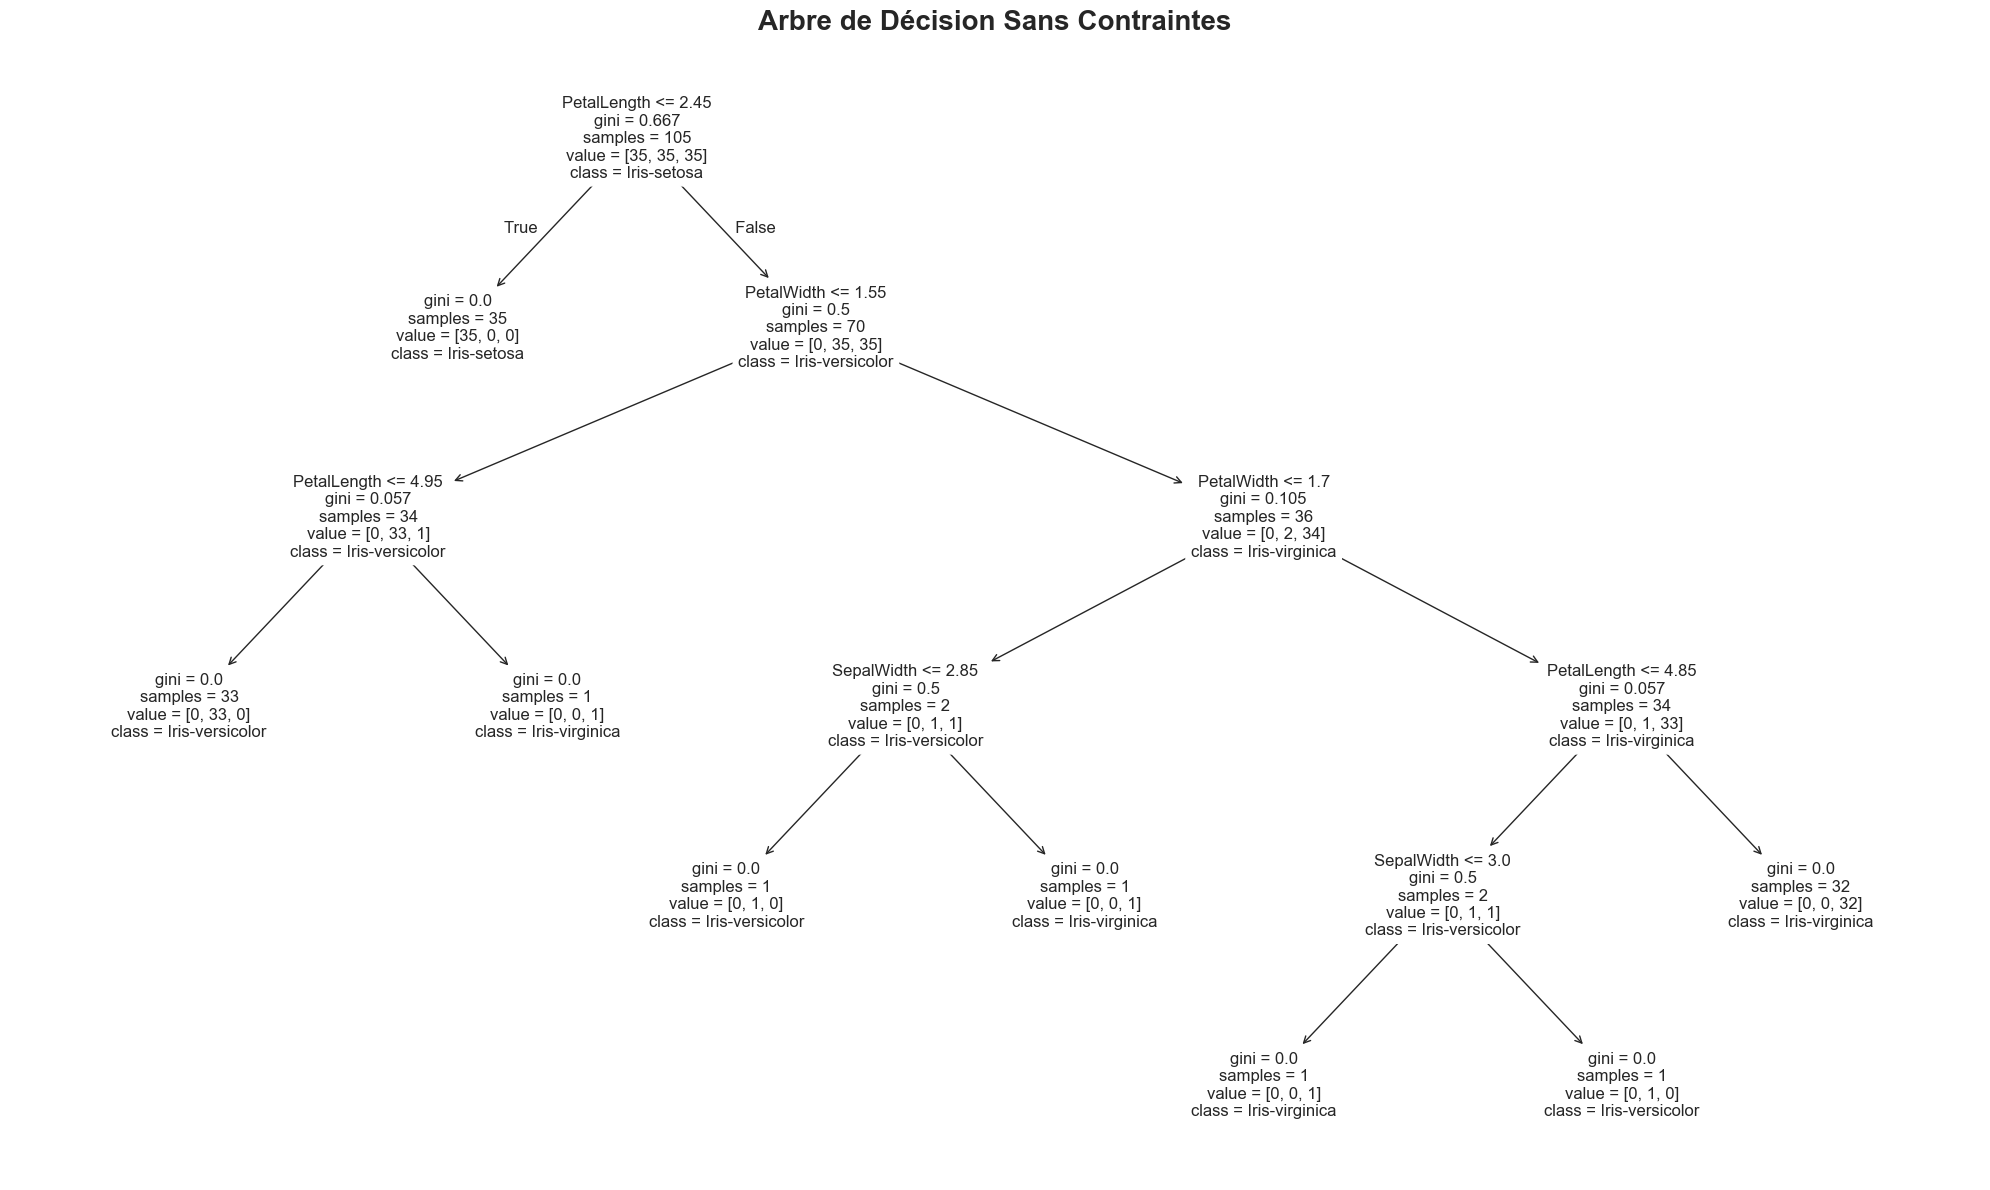

In [156]:
plt.figure(figsize=(20, 12))
plot_tree(dt_unlimited, feature_names=feature_names, 
          class_names=class_names, rounded=True, fontsize=12)
plt.title('Arbre de Décision Sans Contraintes', fontsize=20, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

#### IV.4.3. Profondeur optimale

Explorons désormais l'effet de `max_depth` sur le sur-apprentissage.

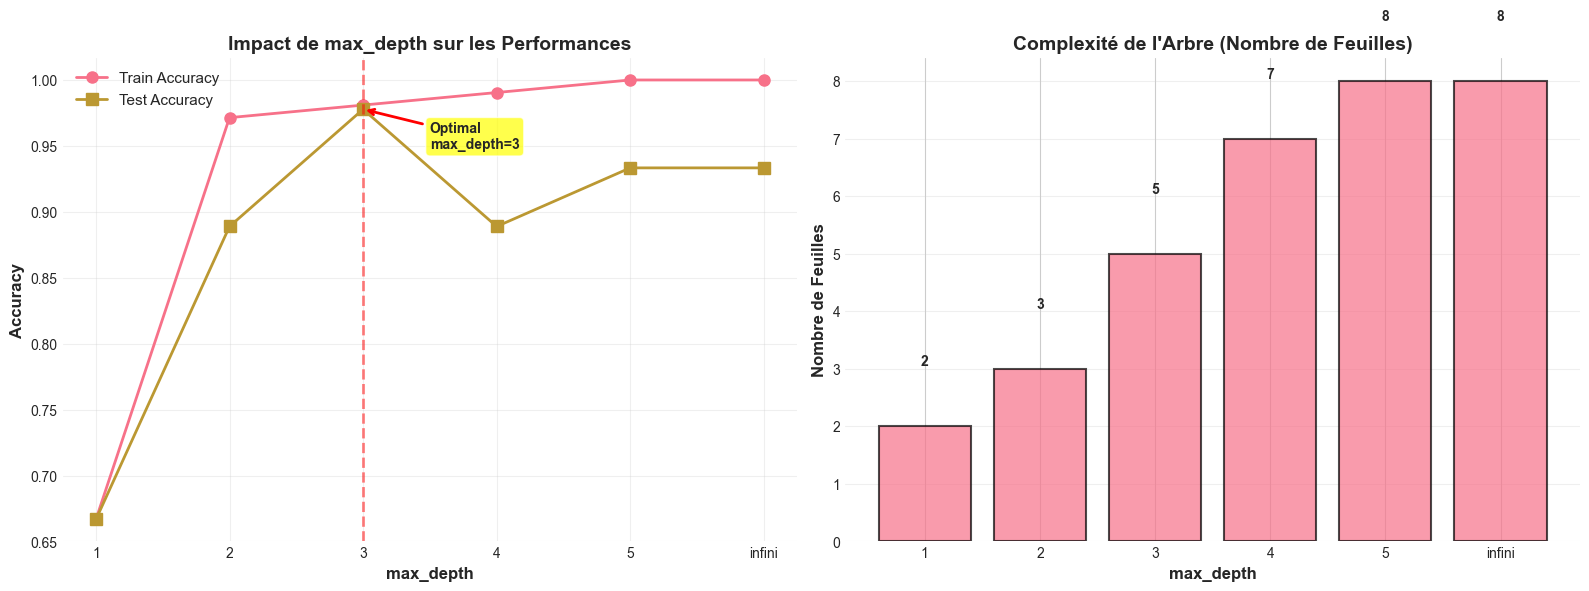

In [157]:
depths = [1, 2, 3, 4, 5, None]
train_scores, test_scores, n_leaves_list = [], [], []

for depth in depths:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, dt.predict(X_train))
    test_acc = accuracy_score(y_test, dt.predict(X_test))
    
    train_scores.append(train_acc)
    test_scores.append(test_acc)
    n_leaves_list.append(dt.get_n_leaves())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

depth_labels = [str(d) if d is not None else "infini" for d in depths]
x_pos = range(len(depths))

ax1.plot(x_pos, train_scores, 'o-', label='Train Accuracy', linewidth=2, markersize=8)
ax1.plot(x_pos, test_scores, 's-', label='Test Accuracy', linewidth=2, markersize=8)
ax1.set_xlabel('max_depth', fontsize=12, fontweight='bold')
ax1.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax1.set_title('Impact de max_depth sur les Performances', fontsize=14, fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(depth_labels)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

best_idx = np.argmax(test_scores)
best_depth = depths[best_idx]
ax1.axvline(x=best_idx, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax1.annotate(f'Optimal\nmax_depth={best_depth}', 
             xy=(best_idx, test_scores[best_idx]), 
             xytext=(best_idx+0.5, test_scores[best_idx]-0.03),
             fontsize=10, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.7),
             arrowprops=dict(arrowstyle='->', color='red', lw=2))

ax2.bar(x_pos, n_leaves_list, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_xlabel('max_depth', fontsize=12, fontweight='bold')
ax2.set_ylabel('Nombre de Feuilles', fontsize=12, fontweight='bold')
ax2.set_title('Complexité de l\'Arbre (Nombre de Feuilles)', fontsize=14, fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(depth_labels)
ax2.grid(axis='y', alpha=0.3)

for i, v in enumerate(n_leaves_list):
    ax2.text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

#### IV.4.4. Comparaison visuelle : arbre optimal vs sur-appris

La profondeur optimale permettra ainsi de produire un arbre beaucoup plus lisible et bien généralisé.

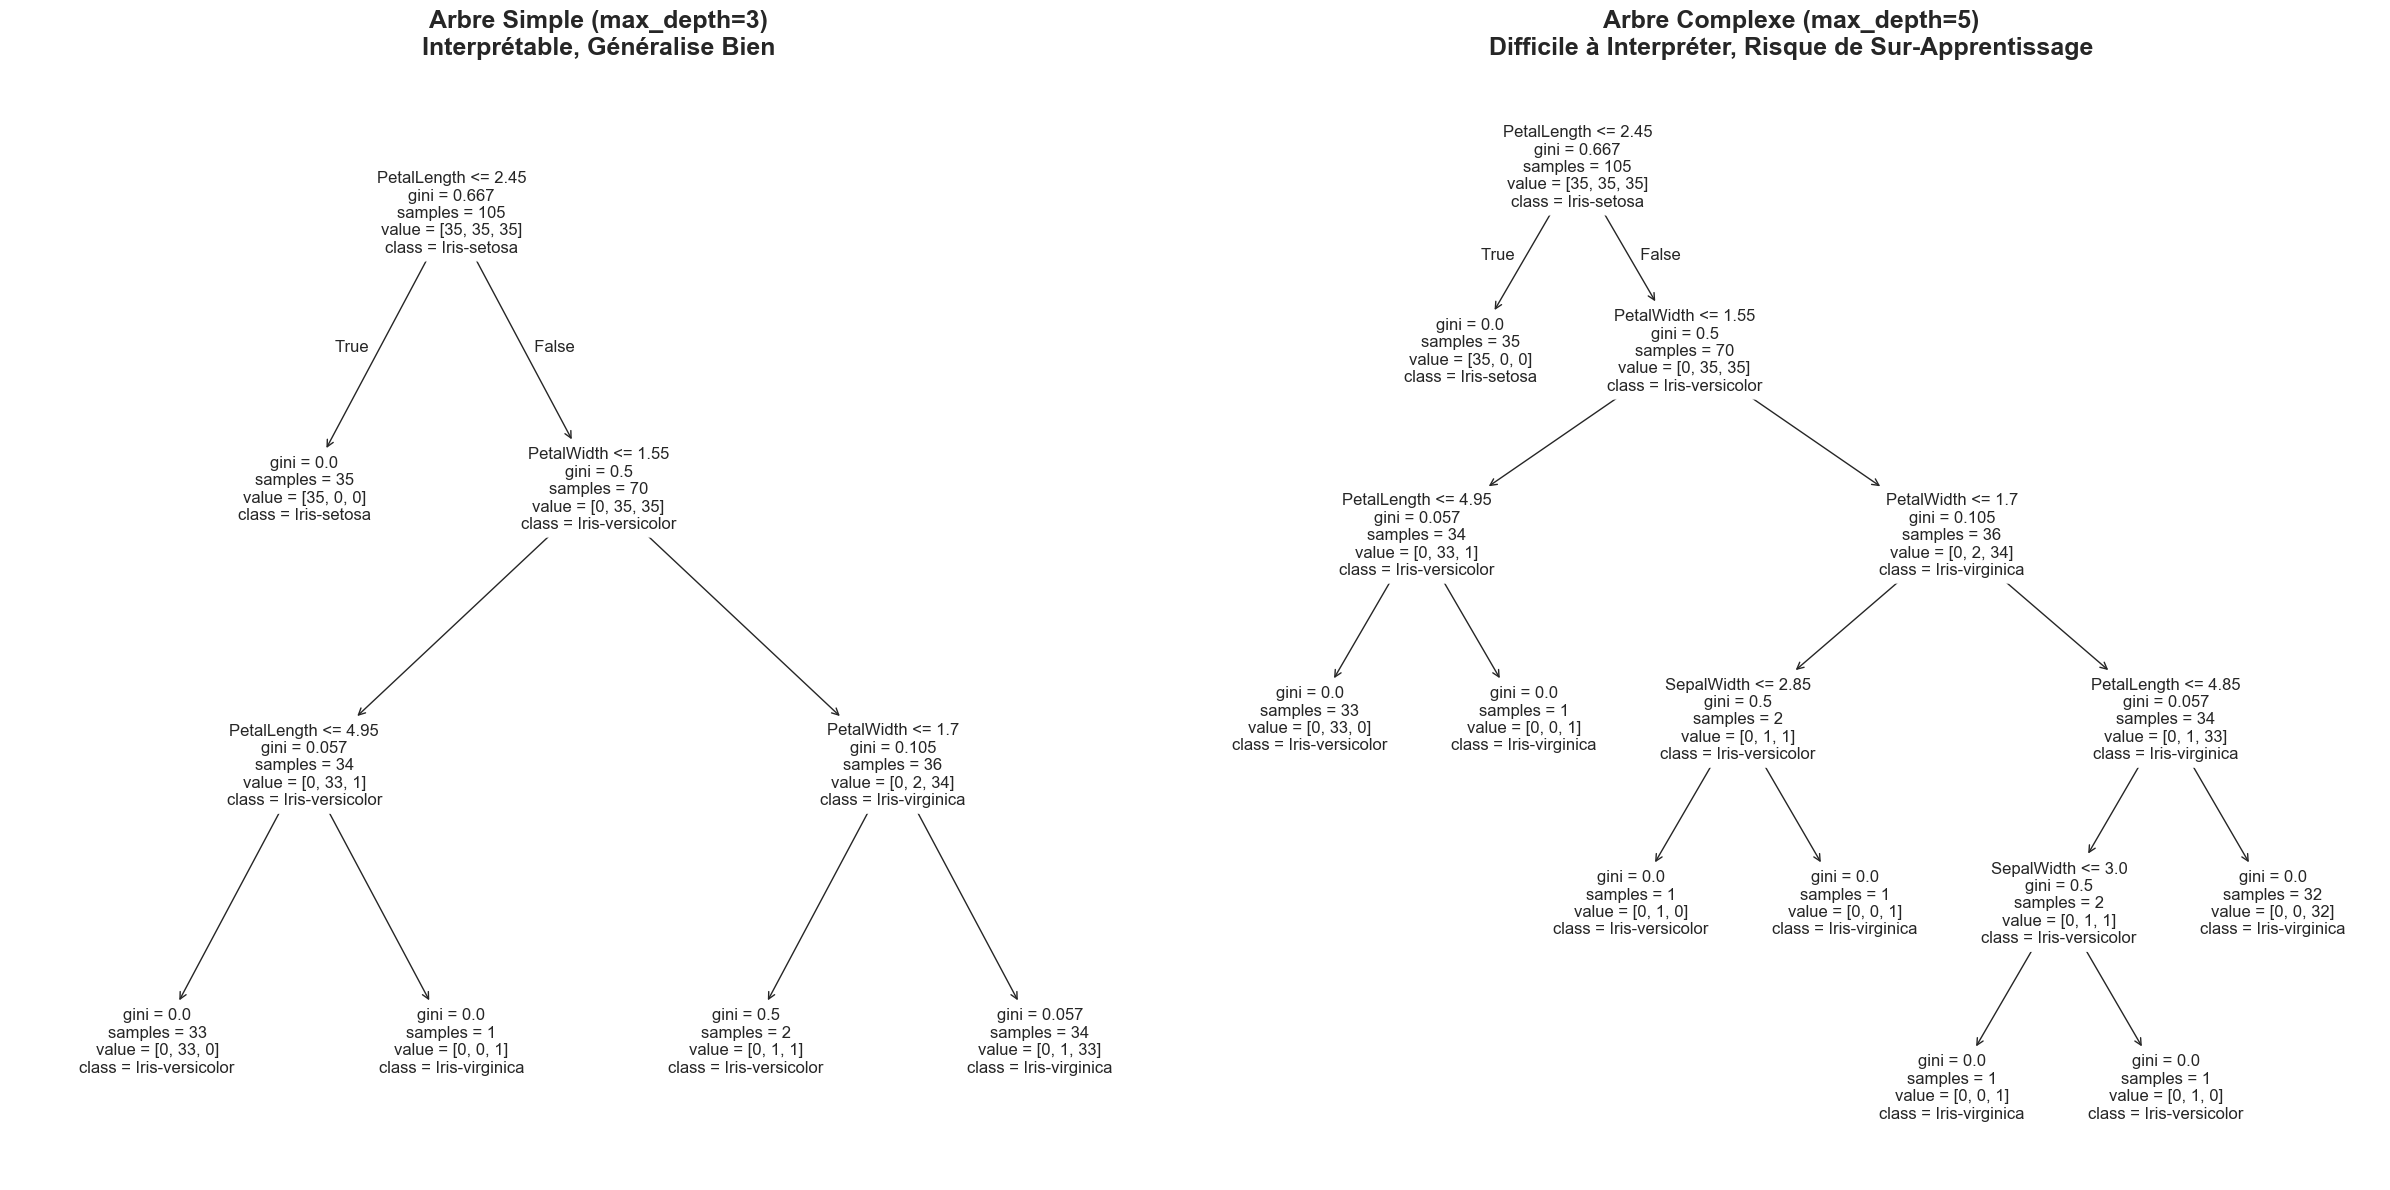

 ================= Accuracy de l'Arbre de Décision : 97.78 % ================= 


In [158]:
dt_optimal = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_optimal.fit(X_train, y_train)

dt_complex = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_complex.fit(X_train, y_train)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(24, 12))

plot_tree(dt_optimal, feature_names=feature_names, class_names=class_names, rounded=True, fontsize=12, ax=ax1)
ax1.set_title(f'Arbre Simple (max_depth={best_depth})\nInterprétable, Généralise Bien', fontsize=18, fontweight='bold', pad=15)

plot_tree(dt_complex, feature_names=feature_names, class_names=class_names, rounded=True, fontsize=12, ax=ax2)
ax2.set_title('Arbre Complexe (max_depth=5)\nDifficile à Interpréter, Risque de Sur-Apprentissage', fontsize=18, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

y_pred_final = dt_optimal.predict(X_test)
acc_tree = accuracy_score(y_test, y_pred_final)
print(f" ================= Accuracy de l'Arbre de Décision : {acc_tree*100:.2f} % ================= ")

##### *Règles de décision au format texte*

In [159]:
print("="*70)
print("REGLES DE DECISION")
print("="*70)
print(export_text(dt_optimal, feature_names=feature_names))

REGLES DE DECISION
|--- PetalLength <= 2.45
|   |--- class: Iris-setosa
|--- PetalLength >  2.45
|   |--- PetalWidth <= 1.55
|   |   |--- PetalLength <= 4.95
|   |   |   |--- class: Iris-versicolor
|   |   |--- PetalLength >  4.95
|   |   |   |--- class: Iris-virginica
|   |--- PetalWidth >  1.55
|   |   |--- PetalWidth <= 1.70
|   |   |   |--- class: Iris-versicolor
|   |   |--- PetalWidth >  1.70
|   |   |   |--- class: Iris-virginica



#### IV.4.5. Importance relative des features

Finalement si l'on souhaite mesurer la contribution globale de chaque feature à la réduction d'impureté à travers tout l'arbre, on peut utiliser l'importance de Gini qui est définie, pour toutes features $j$, comme la somme pondérée des gains d'information obtenus à tous les noeuds qui l'utilisent :

$$\text{Imp}(j) = \sum_{\text{noeuds } t \text{ splitant sur } j} \frac{|\mathcal{D}_t|}{n}\, \text{IG}(\mathcal{D}_t, j, t^*)$$

Une importance nulle signifie donc que la feature n'a été choisie à aucun noeud.

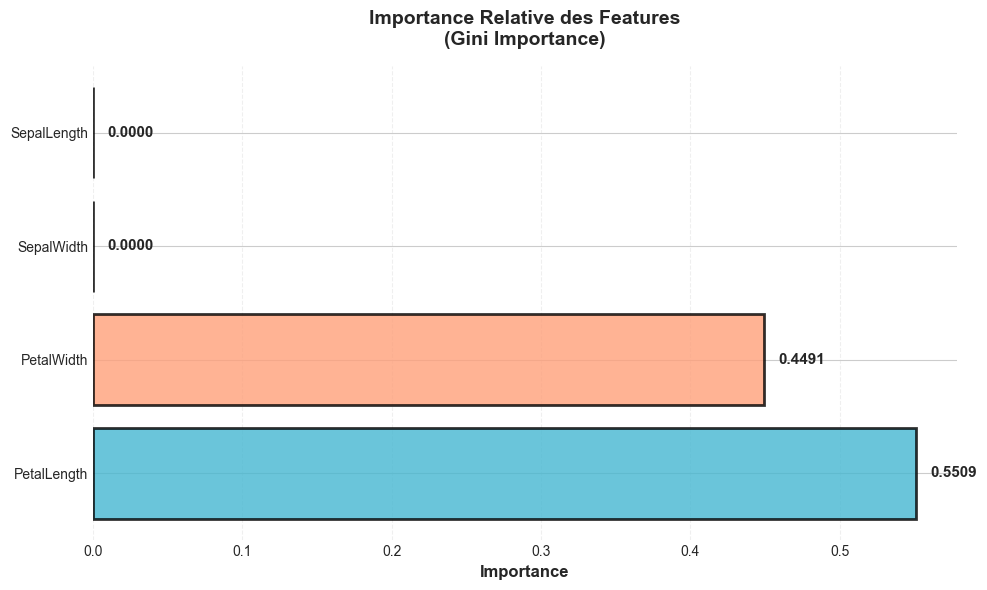

  -> PetalLength est donc la feature la plus discriminante (contribue à 55.1% de la décision totale)


In [160]:
importances = dt_optimal.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = plt.barh(range(len(importances)), importances[indices], color=[colors[i] for i in indices], alpha=0.8, edgecolor='black', linewidth=2)
plt.yticks(range(len(importances)), [feature_names[i] for i in indices])
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.title('Importance Relative des Features\n(Gini Importance)', fontsize=14, fontweight='bold', pad=15)
plt.grid(axis='x', alpha=0.3, linestyle='--')

for i, (bar, imp) in enumerate(zip(bars, importances[indices])):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{imp:.4f}', va='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

print(f"  -> {feature_names[indices[0]]} est donc la feature la plus discriminante (contribue à {importances[indices[0]]*100:.1f}% de la décision totale)")

L'importance des features confirme ainsi complètement ce que l'EDA avait anticipé : les pétales dominent largement la décision. PetalLength concentre plus de la moitié du gain d'information, secondé par PetalWidth qui y contribue aussi de façon significative. Les deux features relatives aux sépales au contraire reçoivent une importance nulle puisque l'arbre n'en a eu besoin à aucun noeud pour améliorer la séparation.

En effet, si on regarde les règles de décisions qui ont été générées, on peut voir que le modèle se sert de PetalLength pour discriminer *Iris setosa*, puis qu'il alterne de PetalWidth à PetalLength pour distinguer *versicolor* et *virginica*.

Néanmoins, il convient de nuancer ce propos face à ce graphique qui indique une séparation très nette. En effet, à noter qu'une importance nulle ne signifie pas que la feature est sans valeur, mais simplement qu'elle n'a pas été sélectionnée par *cet* arbre précis, construit de façon gloutonne sur ce corpus. 

C'est en fait l'une des instabilités caractéristiques des arbres dont la structure peut changer sensiblement selon les données d'entraînement. 

**Note** : Les ***Random Forest***, qui agrège par vote les prédictions de centaines d'arbres construits sur des sous-échantillons aléatoires (bootstrap) différents, fournirait une estimation bien plus stable des importances. La diversité entre les arbres (renforcée en tirant aléatoirement un sous-ensemble de features à chaque split) fait que leurs erreurs se compensent, réduisant drastiquement la variance sans augmenter le biais. Ces méthodes dépassent le cadre de ce chapitre, mais constituent un prolongement naturel pour qui souhaiterait pousser plus loin la classification sur données tabulaires.

#### IV.4.6. Résultats de l'Arbre de Décision

In [161]:
print("="*70)
print("RESULTATS DECISION TREE")
print("="*70)
print(f"\nAccuracy: {acc_tree:.4f} ({acc_tree*100:.2f}%)")
print("\nMatrice de confusion:")
print(confusion_matrix(y_test, y_pred_final))
print("\nRapport de classification:")
print(classification_report(y_test, y_pred_final))

RESULTATS DECISION TREE

Accuracy: 0.9778 (97.78%)

Matrice de confusion:
[[15  0  0]
 [ 0 14  1]
 [ 0  0 15]]

Rapport de classification:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        15
Iris-versicolor       1.00      0.93      0.97        15
 Iris-virginica       0.94      1.00      0.97        15

       accuracy                           0.98        45
      macro avg       0.98      0.98      0.98        45
   weighted avg       0.98      0.98      0.98        45



#### IV.4.7. Analyse d'un chemin de décision

Comme nous l'avons dit, l'un des avantages majeurs des arbres est leur lisibilité, puisqu'il permette de retracer exactement le raisonnement du modèle pour n'importe quelle prédiction. 

Ainsi, on peut analyser le chemin suivi pour fournir la prédiction d'un exemple du test set :

In [162]:
print("="*70)
print("ANALYSE D'UN CHEMIN DE DECISION - Exemple n°27")
print("="*70)

idx = 26
example = X_test[idx:idx+1]
true_class = y_test[idx]
pred_class = dt_optimal.predict(example)[0]

print("\nFeatures:")
for name, value in dict(zip(feature_names, example[0])).items():
    print(f"  - {name}: {value}")

symb = "==" if true_class == pred_class else "!="
print(f"\n  => Vraie classe: {true_class}  {symb}  Prédiction: {pred_class}")

decision_path = dt_optimal.decision_path(example)
node_indicator = decision_path.toarray()[0]
nodes_in_path = np.where(node_indicator == 1)[0]

print(f"\n  Chemin de décision:")
for node_id in nodes_in_path:
    if dt_optimal.tree_.feature[node_id] != -2:  # Pas une feuille
        feature = feature_names[dt_optimal.tree_.feature[node_id]]
        threshold = dt_optimal.tree_.threshold[node_id]
        feature_value = example[0][dt_optimal.tree_.feature[node_id]]
        comparison = "<=" if feature_value <= threshold else ">"
        print(f"    -> {feature} = {feature_value:.2f} {comparison} {threshold:.2f}")
    else:
        print(f"    -> Feuille: Prédiction = {pred_class}")

ANALYSE D'UN CHEMIN DE DECISION - Exemple n°27

Features:
  - SepalLength: 5.4
  - SepalWidth: 3.0
  - PetalLength: 4.5
  - PetalWidth: 1.5

  => Vraie classe: Iris-versicolor  ==  Prédiction: Iris-versicolor

  Chemin de décision:
    -> PetalLength = 4.50 > 2.45
    -> PetalWidth = 1.50 <= 1.55
    -> PetalLength = 4.50 <= 4.95
    -> Feuille: Prédiction = Iris-versicolor


## V. Analyse comparative des méthodes

### V.1. Synthèse des résultats

Maintenant que nous avons implémenté et évalué les cinq modèles de classification sur le dataset Iris, procédons à une analyse comparative des résultats.

TABLEAU COMPARATIF DES PERFORMANCES
         Algorithme  Accuracy             Type    Frontière Multi-classe
      Decision Tree  0.977778 Non-paramétrique Non-linéaire       Native
                KNN  0.977778 Non-paramétrique Non-linéaire       Native
          SVM (RBF)  0.955556    Discriminatif Non-linéaire          OvR
Logistic Regression  0.955556    Discriminatif     Linéaire      Softmax
        Naive Bayes  0.911111        Génératif  Quadratique       Native


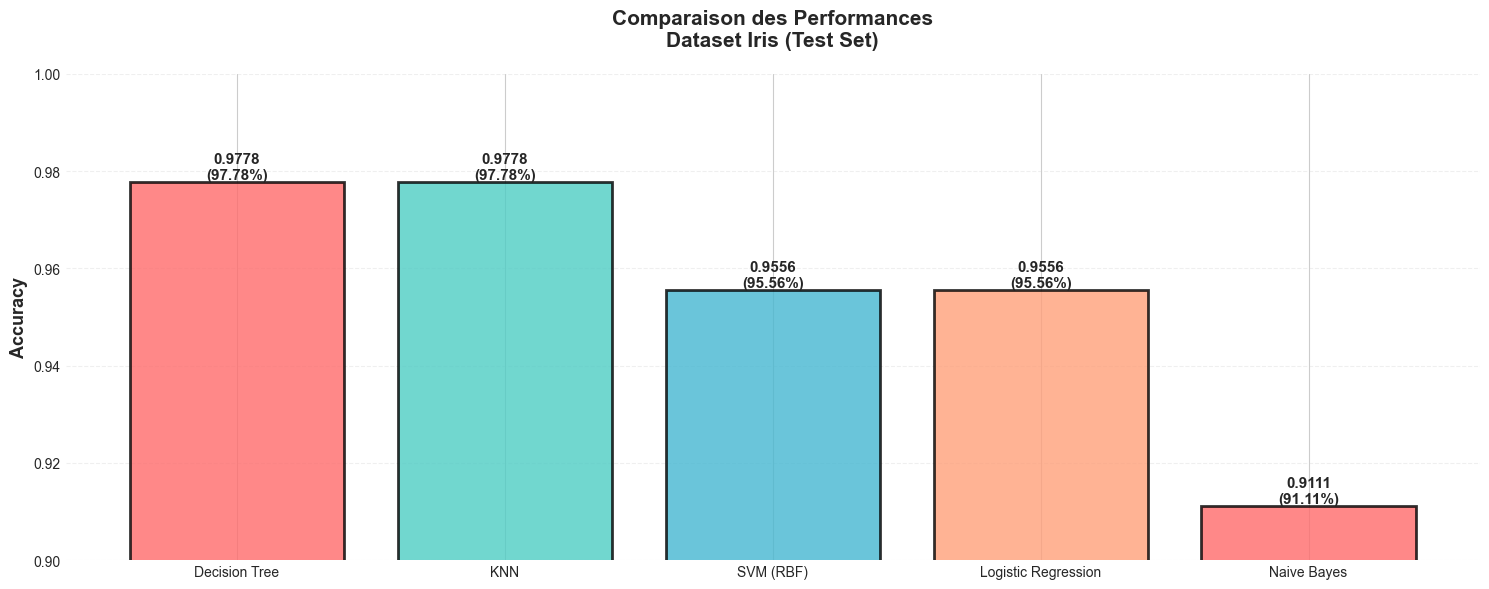

In [163]:
results = {
    'Algorithme': ['SVM (RBF)', 'Logistic Regression', 'Naive Bayes', 'KNN', 'Decision Tree'],
    'Accuracy': [acc_svm, acc_lr, acc_nb, acc_knn, acc_tree],
    'Type': ['Discriminatif', 'Discriminatif', 'Génératif', 'Non-paramétrique', 'Non-paramétrique'],
    'Frontière': ['Non-linéaire', 'Linéaire', 'Quadratique', 'Non-linéaire', 'Non-linéaire'],
    'Multi-classe': ['OvR', 'Softmax', 'Native', 'Native', 'Native']
}

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("="*90)
print("TABLEAU COMPARATIF DES PERFORMANCES")
print("="*90)
print(results_df.to_string(index=False))
print("="*90)

# Visualisation comparative
plt.figure(figsize=(15, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
bars = plt.bar(results_df['Algorithme'], results_df['Accuracy'], color=colors, alpha=0.8, edgecolor='black', linewidth=2)

# Ajouter les valeurs au-dessus des barres
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}\n({height*100:.2f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylabel('Accuracy', fontsize=13, fontweight='bold')
plt.title('Comparaison des Performances\nDataset Iris (Test Set)', fontsize=15, fontweight='bold', pad=20)
plt.ylim([0.9, 1.0])
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

### V.2. Discussion autour des méthodes et de l'EDA

Les cinq modèles atteignent ainsi tous une accuracy élevée, ce qui reflète la structure favorable du dataset utilisé comprenant des classes compactes dont l'une d'elle (*setosa*) est linéairement séparable des deux autres. 

Les différences de performance s'expliquent néanmoins directement par les propriétés que l'EDA avait identifiées.

**Naive Bayes** obtient les performances les plus faibles ($\approx 91$%), dûes à la corrélation $r \simeq 0.96$ entre PetalLength et PetalWidth, qui viole l'hypothèse d'indépendance conditionnelle. Le modèle surestime la vraisemblance des classes pour les exemples dans la zone de chevauchement *versicolor*/*virginica*, d'où les 3 confusions observées dans la matrice de confusion.

**SVM et Régression Logistique** sont équivalentes ($\approx 95-97$%). Comme les deux sont des modèles discriminants linéaires (dans l'espace original ou via le noyau RBF), leur performance similaire suggère que la frontière entre *versicolor* et *virginica* est approximativement linéaire dans l'espace des quatre features. Les erreurs résiduelles correspondent aux exemples dans la zone de chevauchement qui ne peut être résolue par aucune frontière lisse.

**L'arbre de décision** atteint un niveau comparable, mais avec une propriété remarquable puisqu'il n'utilise que PetalLength et PetalWidth, les deux features identifiées comme les plus discriminantes en EDA, et ignore complètement les sépales pour discriminer les classes. Cette sélection de feature pourrait ainsi suggérer une possible amélioration des performances, en limitant l'apprentissage sur ces deux features uniquement.

**KNN** obtient finalement les meilleures performances ($\approx 98$%), avec le résultat contre-intuitif que la version *sans* normalisation surpasse celle avec. En effet, sans normalisation, les features à forte variance naturelle (les pétales) pèsent davantage dans le calcul des distances, ce qui revient à leur accorder implicitement plus d'importance, comme l'EDA le recommandait. 

Ces résultats permettent ainsi d'illustrer un principe essentiel en apprentissage automatique :
> *Comprendre la distribution des données avant de choisir un modèle permet d'anticiper les performances et d'éviter des erreurs que les résultats seuls ne permettraient pas d'expliquer.*

## Conclusion

Dans ce chapitre, nous avons donc pu étendre le cadre de la classification supervisée du cas binaire au multiclasse.

Pour les méthodes déjà abordées dans le chapitre I, on a pu voir que chaque méthode attend une manière différentes de généraliser à $K$ classes. La SVM étend la classification binaire via des stratégies OvR ou OvO. La régression logistique généralise la sigmoïde en une distribution softmax sur $K$ classes. Et Naive Bayes, lui, s'étend trivialement à $K$ classes, de par son approche générative, qui traite nativement un nombre arbitraire de classes.

En complément, on a pu introduire deux nouvelles familles algorithmiques pour la classification. En premier, on a abordé un modèle non-paramétrique, le KNN, qui n'apprend aucune représentation compacte, mais prédit en consultant le voisinage local. Ensuite, on a exploré  les arbres de décision qui partitionne l'espace des features de façon hiérarchique, et produisent des règles explicitement interprétables. Ces deux algorithmes sont natif au multiclasse, mais pour deux raisons différentes : KNN par nature du vote majoritaire et l'arbre de décision par nature du gain d'information.

Finalement, l'enseignement transversal de ce chapitre aura été le rôle central de l'analyse exploratoire avant la construction de modèles. En effet, la corrélation PetalLength/PetalWidth avait prédit les difficultés de Naive Bayes, la séparabilité dans l'espace des pétales avait justifié le noyau RBF, la variance naturelle des features avait anticipé le comportement de KNN sans normalisation et l'importance nulle des sépales dans l'arbre a confirmé notre intuition du pairplot. Chaque résultat numérique de la section V trouve ainsi agréablement son explication dans une observation de la section I.

Le chapitre qui suit prendra une direction différente, en introduisant le concept de réseau de neurones avec le perceptron multicouche (MLP), et les réseaux convolutifs (CNN), pour aborder la classification d'images.

### Références

**Cours universitaires suivis** :
* ***SY02*** : Méthodes statistiques pour l'ingénieur

**Cours universitaires récupérés d'autres étudiants** :
* ***ML01*** : Machine Learning pour tous 

**Ressources en ligne** :
* Documentation [*IBM*](https://www.ibm.com/think/topics/classification-machine-learning)
* Documentation [*Scikit-learn*](https://scikit-learn.org/stable/supervised_learning.html)